In [ ]:
# =============================================================================
# PCOS — DATA CLEANING PIPELINE
# Step 1: Hash + Duplicate Removal + Stratified Split + Save Clean Dataset
# Run this ONCE before any model training
# =============================================================================


# ─────────────────────────────────────────────────────────────────────────────
# BLOCK 1 ▸ INSTALL & MOUNT
# ─────────────────────────────────────────────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# BLOCK 2 ▸ IMPORTS
# ─────────────────────────────────────────────────────────────────────────────
import os
import hashlib
import shutil
import pandas as pd
from tqdm import tqdm
from sklearn.model_selection import train_test_split

print("✅ Imports done")


✅ Imports done


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# BLOCK 3 ▸ PATHS
# ─────────────────────────────────────────────────────────────────────────────
RAW_INFECTED    = "/content/drive/MyDrive/infected"
RAW_NONINFECTED = "/content/drive/MyDrive/noninfected"
CLEAN_DATASET   = "/content/drive/MyDrive/PCOS_Clean_Dataset"

os.makedirs(CLEAN_DATASET, exist_ok=True)

print("✅ Paths set")



✅ Paths set


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# BLOCK 4 ▸ PRINT RAW COUNTS (before cleaning)
# ─────────────────────────────────────────────────────────────────────────────
VALID_EXT = ('.png', '.jpg', '.jpeg', '.bmp')

inf_files    = [f for f in os.listdir(RAW_INFECTED)
                if f.lower().endswith(VALID_EXT)]
noninf_files = [f for f in os.listdir(RAW_NONINFECTED)
                if f.lower().endswith(VALID_EXT)]

print("\n" + "=" * 45)
print("RAW DATASET SUMMARY")
print("=" * 45)
print(f"  PCOS (infected)     : {len(inf_files):>5} images")
print(f"  Non-PCOS            : {len(noninf_files):>5} images")
print(f"  Total               : {len(inf_files)+len(noninf_files):>5} images")
print("=" * 45)




RAW DATASET SUMMARY
  PCOS (infected)     :  6784 images
  Non-PCOS            :  5000 images
  Total               : 11784 images


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# BLOCK 5 ▸ BUILD DATAFRAME
# ─────────────────────────────────────────────────────────────────────────────
filepaths, labels = [], []

for img in os.listdir(RAW_INFECTED):
    if img.lower().endswith(VALID_EXT):
        filepaths.append(os.path.join(RAW_INFECTED, img))
        labels.append(1)

for img in os.listdir(RAW_NONINFECTED):
    if img.lower().endswith(VALID_EXT):
        filepaths.append(os.path.join(RAW_NONINFECTED, img))
        labels.append(0)

df = pd.DataFrame({"filepath": filepaths, "label": labels})

print(f"Total images loaded : {len(df)}")


Total images loaded : 11784


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# BLOCK 6 ▸ MD5 HASH — CHUNK-BASED (memory safe + faster)
# ─────────────────────────────────────────────────────────────────────────────
# ✅ WHY CHUNK-BASED?
#
# Your version:
#   hashlib.md5(f.read()).hexdigest()
#   → reads ENTIRE file into RAM at once
#   → 11784 images × ~500KB = ~5GB RAM spike possible
#   → can crash Colab on large datasets
#
# Chunk-based version:
#   reads file in 8KB pieces
#   → constant ~8KB RAM usage no matter how large the file
#   → safe for any dataset size
#   → same MD5 result — no difference in duplicate detection

def compute_md5(path):
    """
    Memory-safe MD5 hash using 8KB chunks.
    Reads file in small pieces — never loads full image into RAM.
    """
    hash_md5 = hashlib.md5()
    with open(path, "rb") as f:
        for chunk in iter(lambda: f.read(8192), b""):
            hash_md5.update(chunk)
    return hash_md5.hexdigest()


print("Computing hashes (chunk-based, memory safe)...")
df["hash"] = [compute_md5(p) for p in tqdm(df["filepath"])]
print("✅ Hashing complete")


Computing hashes (chunk-based, memory safe)...


100%|██████████| 11784/11784 [38:15<00:00,  5.13it/s]

✅ Hashing complete


In [ ]:

# ─────────────────────────────────────────────────────────────────────────────
# BLOCK 7 ▸ REMOVE DUPLICATES
# ─────────────────────────────────────────────────────────────────────────────
df_clean = df.drop_duplicates(subset="hash").reset_index(drop=True)

removed = len(df) - len(df_clean)

print(f"\nBefore dedup : {len(df)}")
print(f"After dedup  : {len(df_clean)}")
print(f"Removed      : {removed} duplicates")

pcos_count    = (df_clean["label"] == 1).sum()
nonpcos_count = (df_clean["label"] == 0).sum()

print("\n" + "=" * 45)
print("AFTER DUPLICATE REMOVAL")
print("=" * 45)
print(f"  PCOS images        : {pcos_count:>5}")
print(f"  Non-PCOS images    : {nonpcos_count:>5}")
print(f"  Total images       : {len(df_clean):>5}")
print("=" * 45)



Before dedup : 11784
After dedup  : 3996
Removed      : 7788 duplicates

AFTER DUPLICATE REMOVAL
  PCOS images        :  3184
  Non-PCOS images    :   812
  Total images       :  3996


In [ ]:

# ─────────────────────────────────────────────────────────────────────────────
# BLOCK 8 ▸ SAVE CLEAN METADATA
# ─────────────────────────────────────────────────────────────────────────────
metadata_path = os.path.join(CLEAN_DATASET, "metadata_clean.csv")
df_clean.to_csv(metadata_path, index=False)
print(f"✅ Clean metadata saved → {metadata_path}")



✅ Clean metadata saved → /content/drive/MyDrive/PCOS_Clean_Dataset/metadata_clean.csv


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# BLOCK 9 ▸ STRATIFIED TRAIN / VAL / TEST SPLIT  (70 / 15 / 15)
# ─────────────────────────────────────────────────────────────────────────────
train_df, temp_df = train_test_split(
    df_clean,
    test_size    = 0.30,
    stratify     = df_clean["label"],
    random_state = 42
)

val_df, test_df = train_test_split(
    temp_df,
    test_size    = 0.50,
    stratify     = temp_df["label"],
    random_state = 42
)

print("\n" + "=" * 50)
print("DATA SPLIT SUMMARY")
print("=" * 50)

print(f"Train Total  : {len(train_df)}")
print(f"   PCOS      : {(train_df['label']==1).sum()}")
print(f"   Non-PCOS  : {(train_df['label']==0).sum()}")

print(f"\nVal Total    : {len(val_df)}")
print(f"   PCOS      : {(val_df['label']==1).sum()}")
print(f"   Non-PCOS  : {(val_df['label']==0).sum()}")

print(f"\nTest Total   : {len(test_df)}")
print(f"   PCOS      : {(test_df['label']==1).sum()}")
print(f"   Non-PCOS  : {(test_df['label']==0).sum()}")

print("=" * 50)




DATA SPLIT SUMMARY
Train Total  : 2797
   PCOS      : 2229
   Non-PCOS  : 568

Val Total    : 599
   PCOS      : 477
   Non-PCOS  : 122

Test Total   : 600
   PCOS      : 478
   Non-PCOS  : 122


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# BLOCK 10 ▸ CREATE FOLDER STRUCTURE
# ─────────────────────────────────────────────────────────────────────────────
for split in ["train", "val", "test"]:
    for label in ["pcos", "not_pcos"]:
        os.makedirs(os.path.join(CLEAN_DATASET, split, label), exist_ok=True)

print("✅ Directory structure created")

# Final structure:
#
# PCOS_Clean_Dataset/
#   train/
#     pcos/
#     not_pcos/
#   val/
#     pcos/
#     not_pcos/
#   test/
#     pcos/
#     not_pcos/
#   metadata_clean.csv



✅ Directory structure created


In [ ]:

# ─────────────────────────────────────────────────────────────────────────────
# BLOCK 11 ▸ COPY IMAGES TO CLEAN DATASET
# ─────────────────────────────────────────────────────────────────────────────
splits = {
    "train": train_df,
    "val"  : val_df,
    "test" : test_df
}

for split_name, split_df in splits.items():
    print(f"\nCopying {split_name} images...")
    for _, row in tqdm(split_df.iterrows(), total=len(split_df)):
        label_dir = "pcos" if row["label"] == 1 else "not_pcos"
        ext       = os.path.splitext(row["filepath"])[1]
        dst       = os.path.join(
            CLEAN_DATASET, split_name, label_dir,
            f"{row['hash']}{ext}"
        )
        shutil.copy2(row["filepath"], dst)

print("\n✅ Clean dataset saved successfully to Drive")
print(f"   Path : {CLEAN_DATASET}")




Copying train images...


100%|██████████| 2797/2797 [00:38<00:00, 72.43it/s]



Copying val images...


100%|██████████| 599/599 [00:08<00:00, 69.55it/s]



Copying test images...


100%|██████████| 600/600 [00:08<00:00, 69.45it/s]


✅ Clean dataset saved successfully to Drive
   Path : /content/drive/MyDrive/PCOS_Clean_Dataset


In [ ]:

# ─────────────────────────────────────────────────────────────────────────────
# BLOCK 12 ▸ FINAL VERIFICATION
# ─────────────────────────────────────────────────────────────────────────────
print("\n" + "=" * 50)
print("FINAL VERIFICATION")
print("=" * 50)

for split in ["train", "val", "test"]:
    pcos_n    = len(os.listdir(os.path.join(CLEAN_DATASET, split, "pcos")))
    notpcos_n = len(os.listdir(os.path.join(CLEAN_DATASET, split, "not_pcos")))
    print(f"  {split:<6} → pcos: {pcos_n:>4}  |  not_pcos: {notpcos_n:>4}  |  total: {pcos_n+notpcos_n:>4}")

print("=" * 50)
print("\n✅ Data cleaning pipeline COMPLETE")
print("   ▶ Now run the training pipeline (PCOS_PyTorch_Final.py)")


FINAL VERIFICATION
  train  → pcos: 2229  |  not_pcos:  568  |  total: 2797
  val    → pcos:  477  |  not_pcos:  122  |  total:  599
  test   → pcos:  478  |  not_pcos:  122  |  total:  600

✅ Data cleaning pipeline COMPLETE
   ▶ Now run the training pipeline (PCOS_PyTorch_Final.py)


In [ ]:
# =============================================================================
# PCOS DETECTION — PYTORCH RESEARCH PIPELINE
# Publication-Ready | Clinical Metrics | No Errors
# Models: ResNet50 → EfficientNetB0 → DenseNet121 → ViT-B16
# Train one model completely → save everything → next model
# =============================================================================


# ─────────────────────────────────────────────────────────────────────────────
# BLOCK 1 ▸ INSTALL & MOUNT
# ─────────────────────────────────────────────────────────────────────────────
# Run this cell first
# !pip install timm seaborn scikit-learn tqdm

from google.colab import drive
drive.mount('/content/drive')


# ─────────────────────────────────────────────────────────────────────────────
# BLOCK 2 ▸ IMPORTS
# ─────────────────────────────────────────────────────────────────────────────
import os
import gc
import json
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, WeightedRandomSampler

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    matthews_corrcoef,
    log_loss,
    roc_curve,
    precision_recall_curve,
    average_precision_score
)
from sklearn.utils.class_weight import compute_class_weight
from tqdm import tqdm

print("✅ Imports done")
print(f"   PyTorch version : {torch.__version__}")
print(f"   GPU available   : {torch.cuda.is_available()}")


# ─────────────────────────────────────────────────────────────────────────────
# BLOCK 3 ▸ REPRODUCIBILITY
# ─────────────────────────────────────────────────────────────────────────────
def set_seed(seed=42):
    os.environ['PYTHONHASHSEED']          = str(seed)
    os.environ['CUBLAS_WORKSPACE_CONFIG'] = ':4096:8'
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic    = True
    torch.backends.cudnn.benchmark        = False
    torch.use_deterministic_algorithms(True)

set_seed(SEED)
print("✅ Reproducibility set (SEED=42)")


# ─────────────────────────────────────────────────────────────────────────────
# BLOCK 4 ▸ PATHS & CONFIG
# ─────────────────────────────────────────────────────────────────────────────
DATASET_PATH = "/content/drive/MyDrive/PCOS_Clean_Dataset"
TRAIN_DIR    = os.path.join(DATASET_PATH, "train")
VAL_DIR      = os.path.join(DATASET_PATH, "val")
TEST_DIR     = os.path.join(DATASET_PATH, "test")
RESULT_DIR   = "/content/drive/MyDrive/PCOS_Image_Results2"

os.makedirs(RESULT_DIR, exist_ok=True)

DEVICE     = torch.device("cuda" if torch.cuda.is_available() else "cpu")
IMG_SIZE   = 224
BATCH_SIZE = 32
EPOCHS     = 30        # EarlyStopping will stop before this

print("✅ Config ready")
print(f"   Device : {DEVICE}")
print(f"   Paths  : {DATASET_PATH}")


# ─────────────────────────────────────────────────────────────────────────────
# BLOCK 5 ▸ TRANSFORMS
# ─────────────────────────────────────────────────────────────────────────────

# Training: augmentation for clinical image variation
train_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std =[0.229, 0.224, 0.225]
    )
])

# Val / Test: no augmentation, only normalize
val_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std =[0.229, 0.224, 0.225]
    )
])

print("✅ Transforms ready")


# ─────────────────────────────────────────────────────────────────────────────
# BLOCK 6 ▸ DATASETS & DATALOADERS
# ─────────────────────────────────────────────────────────────────────────────
train_ds = datasets.ImageFolder(TRAIN_DIR, transform=train_tf)
val_ds   = datasets.ImageFolder(VAL_DIR,   transform=val_tf)
test_ds  = datasets.ImageFolder(TEST_DIR,  transform=val_tf)

print(f"   Classes   : {train_ds.classes}")
print(f"   Train     : {len(train_ds)} images")
print(f"   Val       : {len(val_ds)} images")
print(f"   Test      : {len(test_ds)} images")

# ── Handle Class Imbalance — Two techniques ───────────────────────────────────
# 1. Compute class weights for loss function
train_labels = [sample[1] for sample in train_ds.samples]

cw_arr = compute_class_weight(
    class_weight = "balanced",
    classes      = np.unique(train_labels),
    y            = train_labels
)
CLASS_WEIGHTS = torch.tensor(cw_arr, dtype=torch.float).to(DEVICE)

# 2. WeightedRandomSampler — ensures balanced batches during training
class_counts   = np.bincount(train_labels)
sample_weights = [1.0 / class_counts[label] for label in train_labels]
sampler        = WeightedRandomSampler(
    weights     = sample_weights,
    num_samples = len(sample_weights),
    replacement = True
)

# DataLoaders
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE,
                          sampler=sampler, num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=2, pin_memory=True)

print(f"\n✅ DataLoaders ready")
print(f"   Class weights → {dict(enumerate(cw_arr.round(4)))}")


# ─────────────────────────────────────────────────────────────────────────────
# BLOCK 7 ▸ EARLY STOPPING
# ─────────────────────────────────────────────────────────────────────────────
class EarlyStopping:
    """
    Monitors val_loss.
    Stops training if no improvement for `patience` epochs.
    Restores best weights automatically via checkpoint.
    """
    def __init__(self, patience=7):
        self.patience  = patience
        self.counter   = 0
        self.best_loss = None
        self.stop      = False

    def step(self, val_loss):
        if self.best_loss is None:
            self.best_loss = val_loss
        elif val_loss >= self.best_loss:
            self.counter += 1
            if self.counter >= self.patience:
                self.stop = True
                print(f"   ⛔ Early stopping triggered (patience={self.patience})")
        else:
            self.best_loss = val_loss
            self.counter   = 0

print("✅ EarlyStopping class ready")


# ─────────────────────────────────────────────────────────────────────────────
# BLOCK 8 ▸ CLINICAL METRICS + FULL METRICS FUNCTION
# ─────────────────────────────────────────────────────────────────────────────
def compute_metrics(y_true, y_pred, y_prob):
    """
    Computes all clinical + standard metrics.
    Returns a dict suitable for JSON save and paper tables.
    """
    cm          = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()

    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    pr_auc      = average_precision_score(y_true, y_prob)

    return {
        "accuracy"           : round(accuracy_score(y_true, y_pred), 4),
        "precision"          : round(precision_score(y_true, y_pred, zero_division=0), 4),
        "recall_sensitivity" : round(sensitivity, 4),
        "specificity"        : round(specificity, 4),
        "f1_score"           : round(f1_score(y_true, y_pred, zero_division=0), 4),
        "roc_auc"            : round(roc_auc_score(y_true, y_prob), 4),
        "pr_auc"             : round(pr_auc, 4),
        "mcc"                : round(matthews_corrcoef(y_true, y_pred), 4),
        "log_loss"           : round(log_loss(y_true, y_prob), 4)
    }

print("✅ Metrics function ready")


# ─────────────────────────────────────────────────────────────────────────────
# BLOCK 9 ▸ PLOT FUNCTIONS
# ─────────────────────────────────────────────────────────────────────────────
def plot_confusion(y_true, y_pred, save_dir, model_name):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["Not PCOS", "PCOS"],
                yticklabels=["Not PCOS", "PCOS"])
    plt.title(f"{model_name} — Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    plt.savefig(os.path.join(save_dir, "confusion_matrix.png"), dpi=150)
    plt.show()
    plt.close()


def plot_roc(y_true, y_prob, save_dir, model_name):
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    auc_val = roc_auc_score(y_true, y_prob)
    plt.figure(figsize=(5, 4))
    plt.plot(fpr, tpr, color="steelblue", lw=2,
             label=f"AUC = {auc_val:.4f}")
    plt.plot([0, 1], [0, 1], "k--", lw=1)
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"{model_name} — ROC Curve")
    plt.legend(loc="lower right")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(os.path.join(save_dir, "roc_curve.png"), dpi=150)
    plt.show()
    plt.close()


def plot_pr(y_true, y_prob, save_dir, model_name):
    p, r, _ = precision_recall_curve(y_true, y_prob)
    pr_auc  = average_precision_score(y_true, y_prob)
    plt.figure(figsize=(5, 4))
    plt.plot(r, p, color="darkorange", lw=2,
             label=f"PR AUC = {pr_auc:.4f}")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(f"{model_name} — Precision-Recall Curve")
    plt.legend(loc="upper right")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(os.path.join(save_dir, "pr_curve.png"), dpi=150)
    plt.show()
    plt.close()


def plot_learning(history, save_dir, model_name):
    # Accuracy curve
    plt.figure(figsize=(8, 5))
    plt.plot(history["train_accuracy"], label="Train", color="steelblue")
    plt.plot(history["val_accuracy"],   label="Val",   color="darkorange")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title(f"{model_name} — Accuracy Learning Curve")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(os.path.join(save_dir, "learning_curve_accuracy.png"), dpi=150)
    plt.show()
    plt.close()

    # Loss curve
    plt.figure(figsize=(8, 5))
    plt.plot(history["train_loss"], label="Train", color="steelblue")
    plt.plot(history["val_loss"],   label="Val",   color="darkorange")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"{model_name} — Loss Learning Curve")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(os.path.join(save_dir, "learning_curve_loss.png"), dpi=150)
    plt.show()
    plt.close()

    # AUC curve
    plt.figure(figsize=(8, 5))
    plt.plot(history["val_roc_auc"], label="Val AUC", color="green")
    plt.xlabel("Epoch")
    plt.ylabel("ROC AUC")
    plt.title(f"{model_name} — AUC Learning Curve")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(os.path.join(save_dir, "learning_curve_auc.png"), dpi=150)
    plt.show()
    plt.close()

print("✅ Plot functions ready")


# ─────────────────────────────────────────────────────────────────────────────
# BLOCK 10 ▸ VALIDATE + TEST FUNCTIONS
# ─────────────────────────────────────────────────────────────────────────────
def validate_epoch(model, criterion):
    """Run one validation pass. Returns val_loss, val_acc, val_auc + full metrics."""
    model.eval()
    y_true, y_pred, y_prob = [], [], []
    total_loss = 0.0

    with torch.no_grad():
        for x, y in val_loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            out  = model(x)
            loss = criterion(out, y)

            prob = torch.softmax(out, dim=1)[:, 1]
            pred = torch.argmax(out, dim=1)

            total_loss += loss.item()
            y_true.extend(y.cpu().numpy())
            y_pred.extend(pred.cpu().numpy())
            y_prob.extend(prob.cpu().numpy())

    val_loss = total_loss / len(val_loader)
    val_acc  = accuracy_score(y_true, y_pred)
    val_auc  = roc_auc_score(y_true, y_prob)
    metrics  = compute_metrics(y_true, y_pred, y_prob)

    return val_loss, val_acc, val_auc, metrics


def evaluate_test(model):
    """Run evaluation on test set. Returns y_true, y_pred, y_prob."""
    model.eval()
    y_true, y_pred, y_prob = [], [], []

    with torch.no_grad():
        for x, y in test_loader:
            x   = x.to(DEVICE)
            out = model(x)

            prob = torch.softmax(out, dim=1)[:, 1]
            pred = torch.argmax(out, dim=1)

            y_true.extend(y.numpy())
            y_pred.extend(pred.cpu().numpy())
            y_prob.extend(prob.cpu().numpy())

    return y_true, y_pred, y_prob

print("✅ Validate + Test functions ready")


# ─────────────────────────────────────────────────────────────────────────────
# BLOCK 11 ▸ MAIN TRAINING FUNCTION
# ─────────────────────────────────────────────────────────────────────────────

# Global list to collect final metrics from all models
model_results = []

def train_model(model_name, model):
    """
    Complete pipeline for one model:
      1. Train with early stopping
      2. Save best checkpoint
      3. Log all metrics every epoch
      4. Evaluate on test set
      5. Save plots, metrics CSV, training log
    """
    print(f"\n{'='*60}")
    print(f"  TRAINING : {model_name}")
    print(f"{'='*60}")

    save_dir = os.path.join(RESULT_DIR, model_name)
    os.makedirs(save_dir, exist_ok=True)

    model     = model.to(DEVICE)
    criterion = nn.CrossEntropyLoss(weight=CLASS_WEIGHTS)
    optimizer = optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-5)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", factor=0.3, patience=3
    )
    early     = EarlyStopping(patience=7)

    # Full history — all metrics stored every epoch
    history = {
        "epoch"            : [],
        "train_loss"       : [],
        "val_loss"         : [],
        "train_accuracy"   : [],
        "val_accuracy"     : [],
        "precision"        : [],
        "recall_sensitivity": [],
        "specificity"      : [],
        "f1_score"         : [],
        "val_roc_auc"      : [],
        "mcc"              : [],
        "log_loss"         : []
    }

    best_val_auc  = 0.0
    best_epoch    = 1

    for epoch in range(1, EPOCHS + 1):

        # ── Training pass ────────────────────────────────────────
        model.train()
        running_loss = 0.0
        correct      = 0
        total        = 0

        for x, y in tqdm(train_loader, desc=f"Epoch {epoch}/{EPOCHS}"):
            x, y = x.to(DEVICE), y.to(DEVICE)
            optimizer.zero_grad()
            out  = model(x)
            loss = criterion(out, y)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            pred          = torch.argmax(out, dim=1)
            correct      += (pred == y).sum().item()
            total        += y.size(0)

        train_loss = running_loss / len(train_loader)
        train_acc  = correct / total

        # ── Validation pass ───────────────────────────────────────
        val_loss, val_acc, val_auc, val_metrics = validate_epoch(model, criterion)

        # LR scheduler step
        scheduler.step(val_loss)

        # ── Store full history ────────────────────────────────────
        history["epoch"].append(epoch)
        history["train_loss"].append(round(train_loss, 6))
        history["val_loss"].append(round(val_loss, 6))
        history["train_accuracy"].append(round(train_acc, 4))
        history["val_accuracy"].append(round(val_acc, 4))
        history["precision"].append(val_metrics["precision"])
        history["recall_sensitivity"].append(val_metrics["recall_sensitivity"])
        history["specificity"].append(val_metrics["specificity"])
        history["f1_score"].append(val_metrics["f1_score"])
        history["val_roc_auc"].append(val_metrics["roc_auc"])
        history["mcc"].append(val_metrics["mcc"])
        history["log_loss"].append(val_metrics["log_loss"])

        print(
            f"   Epoch {epoch:02d} | "
            f"TrainLoss {train_loss:.4f} | "
            f"ValLoss {val_loss:.4f} | "
            f"ValAcc {val_acc:.4f} | "
            f"ValAUC {val_auc:.4f}"
        )

        # ── Save best model by val_auc ────────────────────────────
        if val_auc > best_val_auc:
            best_val_auc = val_auc
            best_epoch   = epoch
            torch.save(
                {
                    "epoch"          : epoch,
                    "model_state"    : model.state_dict(),
                    "optimizer_state": optimizer.state_dict(),
                    "val_auc"        : val_auc,
                    "val_acc"        : val_acc
                },
                os.path.join(save_dir, "best_model.pth")
            )
            print(f"   ✅ Best model saved (AUC={best_val_auc:.4f}, Epoch={epoch})")

        # ── Early stopping check ──────────────────────────────────
        early.step(val_loss)
        if early.stop:
            break

    # ── Save training log CSV ─────────────────────────────────────
    pd.DataFrame(history).to_csv(
        os.path.join(save_dir, "training_log.csv"), index=False
    )
    print(f"\n   📄 Training log saved (best epoch: {best_epoch})")

    # ── Load best model for evaluation ───────────────────────────
    checkpoint = torch.load(os.path.join(save_dir, "best_model.pth"), weights_only=False)
    model.load_state_dict(checkpoint["model_state"])
    print(f"   ✅ Best model loaded for test evaluation")

    # ── Test evaluation ───────────────────────────────────────────
    print(f"\n   Evaluating on test set...")
    y_true, y_pred, y_prob = evaluate_test(model)
    test_metrics = compute_metrics(y_true, y_pred, y_prob)

    print(f"\n{'─'*45}")
    print(f"  TEST RESULTS : {model_name}")
    print(f"{'─'*45}")
    for k, v in test_metrics.items():
        print(f"  {k:<25} : {v:.4f}")

    # ── Save test metrics JSON ────────────────────────────────────
    with open(os.path.join(save_dir, "test_metrics.json"), "w") as f:
        json.dump(test_metrics, f, indent=4)

    # ── Save best epoch info ──────────────────────────────────────
    best_info = {
        "model_name"  : model_name,
        "best_epoch"  : best_epoch,
        "best_val_auc": round(best_val_auc, 4)
    }
    with open(os.path.join(save_dir, "best_epoch_info.json"), "w") as f:
        json.dump(best_info, f, indent=4)

    # ── Save all plots ────────────────────────────────────────────
    plot_confusion(y_true, y_pred, save_dir, model_name)
    plot_roc(y_true, y_prob, save_dir, model_name)
    plot_pr(y_true, y_prob, save_dir, model_name)
    plot_learning(history, save_dir, model_name)

    # ── Add to global comparison list ────────────────────────────
    model_results.append({
        "Model"             : model_name,
        "Accuracy"          : test_metrics["accuracy"],
        "Precision"         : test_metrics["precision"],
        "Sensitivity"       : test_metrics["recall_sensitivity"],
        "Specificity"       : test_metrics["specificity"],
        "F1 Score"          : test_metrics["f1_score"],
        "ROC AUC"           : test_metrics["roc_auc"],
        "PR AUC"            : test_metrics["pr_auc"],
        "MCC"               : test_metrics["mcc"],
        "Log Loss"          : test_metrics["log_loss"],
        "Best Epoch"        : best_epoch
    })

    print(f"\n✅ {model_name} — COMPLETE. All results saved to Drive.")
    print(f"   📁 {save_dir}")

    # Free GPU memory before next model
    del model
    torch.cuda.empty_cache()
    gc.collect()

print("✅ train_model() function ready")
print("   ▶ Now run Model 1 — ResNet50 block")


# =============================================================================
#
#  ██████╗ ███████╗███████╗███╗   ██╗███████╗████████╗███████╗ ██████╗
#  ██╔══██╗██╔════╝██╔════╝████╗  ██║██╔════╝╚══██╔══╝██╔════╝██╔═████╗
#  ██████╔╝█████╗  ███████╗██╔██╗ ██║█████╗     ██║   ███████╗██║██╔██║
#  ██╔══██╗██╔══╝  ╚════██║██║╚██╗██║██╔══╝     ██║   ╚════██║████╔╝██║
#  ██║  ██║███████╗███████║██║ ╚████║███████╗   ██║   ███████║╚██████╔╝
#  ╚═╝  ╚═╝╚══════╝╚══════╝╚═╝  ╚═══╝╚══════╝   ╚═╝   ╚══════╝ ╚═════╝
#                          R E S N E T 5 0
#
# =============================================================================

# ─────────────────────────────────────────────────────────────────────────────
# MODEL 1 ▸ ResNet50  — TRAIN + EVALUATE + SAVE
# ─────────────────────────────────────────────────────────────────────────────
resnet = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
resnet.fc = nn.Linear(resnet.fc.in_features, 2)

train_model("ResNet50", resnet)

print("✅ ResNet50 DONE — proceed to Model 2")


# =============================================================================
#
#  ███████╗███████╗███████╗██╗ ██████╗██╗███████╗███╗   ██╗████████╗
#  ██╔════╝██╔════╝██╔════╝██║██╔════╝██║██╔════╝████╗  ██║╚══██╔══╝
#  █████╗  █████╗  █████╗  ██║██║     ██║█████╗  ██╔██╗ ██║   ██║
#  ██╔══╝  ██╔══╝  ██╔══╝  ██║██║     ██║██╔══╝  ██║╚██╗██║   ██║
#  ███████╗██║     ██║     ██║╚██████╗██║███████╗██║ ╚████║   ██║
#  ╚══════╝╚═╝     ╚═╝     ╚═╝ ╚═════╝╚═╝╚══════╝╚═╝  ╚═══╝   ╚═╝
#                     E F F I C I E N T N E T B 0
#
# =============================================================================

# ─────────────────────────────────────────────────────────────────────────────
# MODEL 2 ▸ EfficientNetB0 — TRAIN + EVALUATE + SAVE
# ─────────────────────────────────────────────────────────────────────────────
efficientnet = models.efficientnet_b0(
    weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1
)
# EfficientNet classifier is Sequential — replace last Linear layer
in_features = efficientnet.classifier[1].in_features
efficientnet.classifier[1] = nn.Linear(in_features, 2)

train_model("EfficientNetB0", efficientnet)

print("✅ EfficientNetB0 DONE — proceed to Model 3")


# =============================================================================
#
#  ██████╗ ███████╗███╗   ██╗███████╗███████╗███╗   ██╗███████╗████████╗
#  ██╔══██╗██╔════╝████╗  ██║██╔════╝██╔════╝████╗  ██║██╔════╝╚══██╔══╝
#  ██║  ██║█████╗  ██╔██╗ ██║███████╗█████╗  ██╔██╗ ██║█████╗     ██║
#  ██║  ██║██╔══╝  ██║╚██╗██║╚════██║██╔══╝  ██║╚██╗██║██╔══╝     ██║
#  ██████╔╝███████╗██║ ╚████║███████║███████╗██║ ╚████║███████╗   ██║
#  ╚═════╝ ╚══════╝╚═╝  ╚═══╝╚══════╝╚══════╝╚═╝  ╚═══╝╚══════╝   ╚═╝
#                       D E N S E N E T 1 2 1
#
# =============================================================================

# ─────────────────────────────────────────────────────────────────────────────
# MODEL 3 ▸ DenseNet121 — TRAIN + EVALUATE + SAVE
# ─────────────────────────────────────────────────────────────────────────────
densenet = models.densenet121(
    weights=models.DenseNet121_Weights.IMAGENET1K_V1
)
densenet.classifier = nn.Linear(densenet.classifier.in_features, 2)

train_model("DenseNet121", densenet)

print("✅ DenseNet121 DONE — proceed to Model 4")


# =============================================================================
#
#  ██╗   ██╗██╗████████╗    ██████╗  ██╗ ██████╗
#  ██║   ██║██║╚══██╔══╝    ██╔══██╗███║██╔════╝
#  ██║   ██║██║   ██║       ██████╔╝╚██║███████╗
#  ╚██╗ ██╔╝██║   ██║       ██╔══██╗ ██║██╔══██║
#   ╚████╔╝ ██║   ██║       ██████╔╝ ██║╚██████║
#    ╚═══╝  ╚═╝   ╚═╝       ╚═════╝  ╚═╝ ╚═════╝
#           V I S I O N   T R A N S F O R M E R
#
# =============================================================================

# ─────────────────────────────────────────────────────────────────────────────
# MODEL 4 ▸ Vision Transformer (ViT-B16) — TRAIN + EVALUATE + SAVE
# ─────────────────────────────────────────────────────────────────────────────
vit = models.vit_b_16(weights=models.ViT_B_16_Weights.IMAGENET1K_V1)
vit.heads.head = nn.Linear(vit.heads.head.in_features, 2)

train_model("ViT_B16", vit)

print("✅ ViT_B16 DONE")




# =============================================================================
#
#  ███╗   ███╗ ██████╗ ██████╗ ██╗██╗     ███████╗███╗   ██╗███████╗████████╗
#  ████╗ ████║██╔═══██╗██╔══██╗██║██║     ██╔════╝████╗  ██║██╔════╝╚══██╔══╝
#  ██╔████╔██║██║   ██║██████╔╝██║██║     █████╗  ██╔██╗ ██║█████╗     ██║
#  ██║╚██╔╝██║██║   ██║██╔══██╗██║██║     ██╔══╝  ██║╚██╗██║██╔══╝     ██║
#  ██║ ╚═╝ ██║╚██████╔╝██████╔╝██║███████╗███████╗██║ ╚████║███████╗   ██║
#  ╚═╝     ╚═╝ ╚═════╝ ╚═════╝ ╚═╝╚══════╝╚══════╝╚═╝  ╚═══╝╚══════╝   ╚═╝
#                        M O B I L E N E T V 2
#
# =============================================================================

# ─────────────────────────────────────────────────────────────────────────────
# MODEL 5 ▸ MobileNetV2 — TRAIN + EVALUATE + SAVE
# ─────────────────────────────────────────────────────────────────────────────
mobilenet = models.mobilenet_v2(
    weights=models.MobileNet_V2_Weights.IMAGENET1K_V1
)
# MobileNetV2 classifier is Sequential[Dropout, Linear] — replace Linear
mobilenet.classifier[1] = nn.Linear(mobilenet.classifier[1].in_features, 2)

train_model("MobileNetV2", mobilenet)

print("✅ MobileNetV2 DONE")


# =============================================================================
# FINAL BLOCK ▸ MODEL COMPARISON TABLE
# Run after ALL 4 models are trained
# =============================================================================

print("\n" + "=" * 70)
print("  FINAL COMPARISON — ALL MODELS")
print("=" * 70)

comparison_df = pd.DataFrame(model_results)

# Rename columns to match bar chart keys
comparison_df = comparison_df.rename(columns={
    "accuracy"   : "Accuracy",
    "precision"  : "Precision",
    "recall_sensitivity": "Sensitivity",
    "specificity": "Specificity",
    "f1_score"   : "F1 Score",
    "roc_auc"    : "ROC AUC",
    "pr_auc"     : "PR AUC",
    "mcc"        : "MCC",
    "log_loss"   : "Log Loss"
})

print(comparison_df.to_string(index=False))

# Save CSV
comparison_df.to_csv(
    os.path.join(RESULT_DIR, "model_comparison.csv"), index=False
)
print(f"\n✅ Comparison table saved → {RESULT_DIR}/model_comparison.csv")

# ── Bar chart comparison ──────────────────────────────────────────────────────
metrics_to_plot = ["Accuracy", "Sensitivity", "Specificity", "F1 Score", "ROC AUC"]
colors          = ["steelblue", "darkorange", "green", "crimson", "purple"]

fig, axes = plt.subplots(1, len(metrics_to_plot), figsize=(25, 5))

for i, metric in enumerate(metrics_to_plot):
    bars = axes[i].bar(comparison_df["Model"], comparison_df[metric],
                       color=colors)
    axes[i].set_title(metric, fontsize=12, fontweight="bold")
    axes[i].set_ylim(0.5, 1.05)
    axes[i].tick_params(axis="x", rotation=30)
    axes[i].grid(axis="y", alpha=0.3)
    for bar, val in zip(bars, comparison_df[metric]):
        axes[i].text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.005,
            f"{val:.3f}", ha="center", va="bottom", fontsize=8
        )

plt.suptitle("PCOS Detection — Model Comparison (Clinical Metrics)",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(RESULT_DIR, "model_comparison_chart.png"), dpi=150)
plt.show()
plt.close()

print("\n🎉 ALL MODELS COMPLETE!")
print(f"📁 Everything saved → {RESULT_DIR}")
print("\nOutput per model:")
print("  best_model.pth          — best checkpoint (restorable)")
print("  test_metrics.json       — all test metrics")
print("  training_log.csv        — epoch-wise full metric history")
print("  best_epoch_info.json    — best epoch + best AUC")
print("  confusion_matrix.png")
print("  roc_curve.png")
print("  pr_curve.png")
print("  learning_curve_accuracy.png")
print("  learning_curve_loss.png")
print("  learning_curve_auc.png")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Imports done
   PyTorch version : 2.10.0+cu128
   GPU available   : True
✅ Reproducibility set (SEED=42)
✅ Config ready
   Device : cuda
   Paths  : /content/drive/MyDrive/PCOS_Clean_Dataset
✅ Transforms ready
   Classes   : ['not_pcos', 'pcos']
   Train     : 2797 images
   Val       : 599 images
   Test      : 600 images

✅ DataLoaders ready
   Class weights → {0: np.float64(2.4621), 1: np.float64(0.6274)}
✅ EarlyStopping class ready
✅ Metrics function ready
✅ Plot functions ready
✅ Validate + Test functions ready
✅ train_model() function ready
   ▶ Now run Model 1 — ResNet50 block

  TRAINING : ResNet50


Epoch 1/30:  86%|████████▋ | 76/88 [00:37<00:05,  2.01it/s]


KeyboardInterrupt: 

In [ ]:
# =============================================================================
# PCOS DETECTION — PYTORCH RESEARCH PIPELINE
# Publication-Ready | Clinical Metrics | No Errors
# Models: ResNet50 → EfficientNetB0 → DenseNet121 → ViT-B16
# Train one model completely → save everything → next model
# =============================================================================


# ─────────────────────────────────────────────────────────────────────────────
# BLOCK 1 ▸ INSTALL & MOUNT
# ─────────────────────────────────────────────────────────────────────────────
# Run this cell first
# !pip install timm seaborn scikit-learn tqdm

from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# BLOCK 2 ▸ IMPORTS
# ─────────────────────────────────────────────────────────────────────────────
import os
import gc
import json
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, WeightedRandomSampler

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    matthews_corrcoef,
    log_loss,
    roc_curve,
    precision_recall_curve,
    average_precision_score
)
from sklearn.utils.class_weight import compute_class_weight
from tqdm import tqdm

print("✅ Imports done")
print(f"   PyTorch version : {torch.__version__}")
print(f"   GPU available   : {torch.cuda.is_available()}")


✅ Imports done
   PyTorch version : 2.10.0+cu128
   GPU available   : True


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# BLOCK 3 ▸ REPRODUCIBILITY
# ─────────────────────────────────────────────────────────────────────────────
SEED = 42
def set_seed(seed=42):
    os.environ['PYTHONHASHSEED']          = str(seed)
    os.environ['CUBLAS_WORKSPACE_CONFIG'] = ':4096:8'
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic    = True
    torch.backends.cudnn.benchmark        = False
    torch.use_deterministic_algorithms(True)

set_seed(SEED)
print("✅ Reproducibility set (SEED=42)")

✅ Reproducibility set (SEED=42)


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# BLOCK 4 ▸ PATHS & CONFIG
# ─────────────────────────────────────────────────────────────────────────────
DATASET_PATH = "/content/drive/MyDrive/PCOS_Clean_Dataset"
TRAIN_DIR    = os.path.join(DATASET_PATH, "train")
VAL_DIR      = os.path.join(DATASET_PATH, "val")
TEST_DIR     = os.path.join(DATASET_PATH, "test")
RESULT_DIR   = "/content/drive/MyDrive/PCOS_Image_Results2"

os.makedirs(RESULT_DIR, exist_ok=True)

DEVICE     = torch.device("cuda" if torch.cuda.is_available() else "cpu")
IMG_SIZE   = 224
BATCH_SIZE = 32
EPOCHS     = 30        # EarlyStopping will stop before this

print("✅ Config ready")
print(f"   Device : {DEVICE}")
print(f"   Paths  : {DATASET_PATH}")


✅ Config ready
   Device : cuda
   Paths  : /content/drive/MyDrive/PCOS_Clean_Dataset


In [ ]:

# ─────────────────────────────────────────────────────────────────────────────
# BLOCK 5 ▸ TRANSFORMS
# ─────────────────────────────────────────────────────────────────────────────

# Training: augmentation for clinical image variation
train_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std =[0.229, 0.224, 0.225]
    )
])

# Val / Test: no augmentation, only normalize
val_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std =[0.229, 0.224, 0.225]
    )
])

print("✅ Transforms ready")



✅ Transforms ready


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# BLOCK 6 ▸ DATASETS & DATALOADERS
# ─────────────────────────────────────────────────────────────────────────────
set_seed(SEED)
train_ds = datasets.ImageFolder(TRAIN_DIR, transform=train_tf)
val_ds   = datasets.ImageFolder(VAL_DIR,   transform=val_tf)
test_ds  = datasets.ImageFolder(TEST_DIR,  transform=val_tf)

print(f"   Classes   : {train_ds.classes}")
print(f"   Train     : {len(train_ds)} images")
print(f"   Val       : {len(val_ds)} images")
print(f"   Test      : {len(test_ds)} images")

# ── Handle Class Imbalance — Two techniques ───────────────────────────────────
# 1. Compute class weights for loss function
train_labels = [sample[1] for sample in train_ds.samples]

cw_arr = compute_class_weight(
    class_weight = "balanced",
    classes      = np.unique(train_labels),
    y            = train_labels
)
CLASS_WEIGHTS = torch.tensor(cw_arr, dtype=torch.float).to(DEVICE)

# 2. WeightedRandomSampler — ensures balanced batches during training
class_counts   = np.bincount(train_labels)
sample_weights = [1.0 / class_counts[label] for label in train_labels]
sampler_g = torch.Generator()
sampler_g.manual_seed(42)

sampler = WeightedRandomSampler(
    weights     = sample_weights,
    num_samples = len(sample_weights),
    replacement = True,
    generator   = sampler_g
)

# DataLoaders
def seed_worker(worker_id):
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)

loader_g = torch.Generator()
loader_g.manual_seed(42)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE,
                          sampler=sampler, num_workers=2, pin_memory=True,
                          worker_init_fn=seed_worker, generator=loader_g)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=2, pin_memory=True,
                          worker_init_fn=seed_worker)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=2, pin_memory=True,
                          worker_init_fn=seed_worker)

print(f"\n✅ DataLoaders ready")
print(f"   Class weights → {dict(enumerate(cw_arr.round(4)))}")



   Classes   : ['not_pcos', 'pcos']
   Train     : 2797 images
   Val       : 599 images
   Test      : 600 images

✅ DataLoaders ready
   Class weights → {0: np.float64(2.4621), 1: np.float64(0.6274)}


In [ ]:

# ─────────────────────────────────────────────────────────────────────────────
# BLOCK 7 ▸ EARLY STOPPING
# ─────────────────────────────────────────────────────────────────────────────
class EarlyStopping:
    """
    Monitors val_loss.
    Stops training if no improvement for `patience` epochs.
    Restores best weights automatically via checkpoint.
    """
    def __init__(self, patience=7):
        self.patience  = patience
        self.counter   = 0
        self.best_loss = None
        self.stop      = False

    def step(self, val_loss):
        if self.best_loss is None:
            self.best_loss = val_loss
        elif val_loss >= self.best_loss:
            self.counter += 1
            if self.counter >= self.patience:
                self.stop = True
                print(f"   ⛔ Early stopping triggered (patience={self.patience})")
        else:
            self.best_loss = val_loss
            self.counter   = 0

print("✅ EarlyStopping class ready")



✅ EarlyStopping class ready


In [ ]:


# ─────────────────────────────────────────────────────────────────────────────
# BLOCK 8 ▸ CLINICAL METRICS + FULL METRICS FUNCTION
# ─────────────────────────────────────────────────────────────────────────────
def compute_metrics(y_true, y_pred, y_prob):
    """
    Computes all clinical + standard metrics.
    Returns a dict suitable for JSON save and paper tables.
    """
    cm          = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()

    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    pr_auc      = average_precision_score(y_true, y_prob)

    return {
        "accuracy"           : round(accuracy_score(y_true, y_pred), 4),
        "precision"          : round(precision_score(y_true, y_pred, zero_division=0), 4),
        "recall_sensitivity" : round(sensitivity, 4),
        "specificity"        : round(specificity, 4),
        "f1_score"           : round(f1_score(y_true, y_pred, zero_division=0), 4),
        "roc_auc"            : round(roc_auc_score(y_true, y_prob), 4),
        "pr_auc"             : round(pr_auc, 4),
        "mcc"                : round(matthews_corrcoef(y_true, y_pred), 4),
        "log_loss"           : round(log_loss(y_true, y_prob), 4)
    }

print("✅ Metrics function ready")



✅ Metrics function ready


In [ ]:

# ─────────────────────────────────────────────────────────────────────────────
# BLOCK 9 ▸ PLOT FUNCTIONS
# ─────────────────────────────────────────────────────────────────────────────
def plot_confusion(y_true, y_pred, save_dir, model_name):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["Not PCOS", "PCOS"],
                yticklabels=["Not PCOS", "PCOS"])
    plt.title(f"{model_name} — Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    plt.savefig(os.path.join(save_dir, "confusion_matrix.png"), dpi=150)
    plt.show()
    plt.close()


def plot_roc(y_true, y_prob, save_dir, model_name):
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    auc_val = roc_auc_score(y_true, y_prob)
    plt.figure(figsize=(5, 4))
    plt.plot(fpr, tpr, color="steelblue", lw=2,
             label=f"AUC = {auc_val:.4f}")
    plt.plot([0, 1], [0, 1], "k--", lw=1)
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"{model_name} — ROC Curve")
    plt.legend(loc="lower right")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(os.path.join(save_dir, "roc_curve.png"), dpi=150)
    plt.show()
    plt.close()


def plot_pr(y_true, y_prob, save_dir, model_name):
    p, r, _ = precision_recall_curve(y_true, y_prob)
    pr_auc  = average_precision_score(y_true, y_prob)
    plt.figure(figsize=(5, 4))
    plt.plot(r, p, color="darkorange", lw=2,
             label=f"PR AUC = {pr_auc:.4f}")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(f"{model_name} — Precision-Recall Curve")
    plt.legend(loc="upper right")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(os.path.join(save_dir, "pr_curve.png"), dpi=150)
    plt.show()
    plt.close()


def plot_learning(history, save_dir, model_name):
    # Accuracy curve
    plt.figure(figsize=(8, 5))
    plt.plot(history["train_accuracy"], label="Train", color="steelblue")
    plt.plot(history["val_accuracy"],   label="Val",   color="darkorange")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title(f"{model_name} — Accuracy Learning Curve")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(os.path.join(save_dir, "learning_curve_accuracy.png"), dpi=150)
    plt.show()
    plt.close()

    # Loss curve
    plt.figure(figsize=(8, 5))
    plt.plot(history["train_loss"], label="Train", color="steelblue")
    plt.plot(history["val_loss"],   label="Val",   color="darkorange")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"{model_name} — Loss Learning Curve")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(os.path.join(save_dir, "learning_curve_loss.png"), dpi=150)
    plt.show()
    plt.close()

    # AUC curve
    plt.figure(figsize=(8, 5))
    plt.plot(history["val_roc_auc"], label="Val AUC", color="green")
    plt.xlabel("Epoch")
    plt.ylabel("ROC AUC")
    plt.title(f"{model_name} — AUC Learning Curve")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(os.path.join(save_dir, "learning_curve_auc.png"), dpi=150)
    plt.show()
    plt.close()

print("✅ Plot functions ready")

✅ Plot functions ready


In [ ]:

# ─────────────────────────────────────────────────────────────────────────────
# BLOCK 10 ▸ VALIDATE + TEST FUNCTIONS
# ─────────────────────────────────────────────────────────────────────────────
def validate_epoch(model, criterion):
    """Run one validation pass. Returns val_loss, val_acc, val_auc + full metrics."""
    model.eval()
    y_true, y_pred, y_prob = [], [], []
    total_loss = 0.0

    with torch.no_grad():
        for x, y in val_loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            out  = model(x)
            loss = criterion(out, y)

            prob = torch.softmax(out, dim=1)[:, 1]
            pred = torch.argmax(out, dim=1)

            total_loss += loss.item()
            y_true.extend(y.cpu().numpy())
            y_pred.extend(pred.cpu().numpy())
            y_prob.extend(prob.cpu().numpy())

    val_loss = total_loss / len(val_loader)
    val_acc  = accuracy_score(y_true, y_pred)
    val_auc  = roc_auc_score(y_true, y_prob)
    metrics  = compute_metrics(y_true, y_pred, y_prob)

    return val_loss, val_acc, val_auc, metrics


def evaluate_test(model):
    """Run evaluation on test set. Returns y_true, y_pred, y_prob."""
    model.eval()
    y_true, y_pred, y_prob = [], [], []

    with torch.no_grad():
        for x, y in test_loader:
            x   = x.to(DEVICE)
            out = model(x)

            prob = torch.softmax(out, dim=1)[:, 1]
            pred = torch.argmax(out, dim=1)

            y_true.extend(y.numpy())
            y_pred.extend(pred.cpu().numpy())
            y_prob.extend(prob.cpu().numpy())

    return y_true, y_pred, y_prob

print("✅ Validate + Test functions ready")


✅ Validate + Test functions ready


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# BLOCK 11 ▸ MAIN TRAINING FUNCTION
# ─────────────────────────────────────────────────────────────────────────────

# Global list to collect final metrics from all models
model_results = []

def train_model(model_name, model):
    """
    Complete pipeline for one model:
      1. Train with early stopping
      2. Save best checkpoint
      3. Log all metrics every epoch
      4. Evaluate on test set
      5. Save plots, metrics CSV, training log
    """
    set_seed(SEED)
    print(f"\n{'='*60}")
    print(f"  TRAINING : {model_name}")
    print(f"{'='*60}")

    save_dir = os.path.join(RESULT_DIR, model_name)
    os.makedirs(save_dir, exist_ok=True)

    model     = model.to(DEVICE)
    criterion = nn.CrossEntropyLoss(weight=CLASS_WEIGHTS)
    optimizer = optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-5)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", factor=0.3, patience=3
    )
    early     = EarlyStopping(patience=7)

    # Full history — all metrics stored every epoch
    history = {
        "epoch"            : [],
        "train_loss"       : [],
        "val_loss"         : [],
        "train_accuracy"   : [],
        "val_accuracy"     : [],
        "precision"        : [],
        "recall_sensitivity": [],
        "specificity"      : [],
        "f1_score"         : [],
        "val_roc_auc"      : [],
        "mcc"              : [],
        "log_loss"         : []
    }

    best_val_auc  = 0.0
    best_epoch    = 1

    for epoch in range(1, EPOCHS + 1):

        # ── Training pass ────────────────────────────────────────
        model.train()
        running_loss = 0.0
        correct      = 0
        total        = 0

        for x, y in tqdm(train_loader, desc=f"Epoch {epoch}/{EPOCHS}"):
            x, y = x.to(DEVICE), y.to(DEVICE)
            optimizer.zero_grad()
            out  = model(x)
            loss = criterion(out, y)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            pred          = torch.argmax(out, dim=1)
            correct      += (pred == y).sum().item()
            total        += y.size(0)

        train_loss = running_loss / len(train_loader)
        train_acc  = correct / total

        # ── Validation pass ───────────────────────────────────────
        val_loss, val_acc, val_auc, val_metrics = validate_epoch(model, criterion)

        # LR scheduler step
        scheduler.step(val_loss)

        # ── Store full history ────────────────────────────────────
        history["epoch"].append(epoch)
        history["train_loss"].append(round(train_loss, 6))
        history["val_loss"].append(round(val_loss, 6))
        history["train_accuracy"].append(round(train_acc, 4))
        history["val_accuracy"].append(round(val_acc, 4))
        history["precision"].append(val_metrics["precision"])
        history["recall_sensitivity"].append(val_metrics["recall_sensitivity"])
        history["specificity"].append(val_metrics["specificity"])
        history["f1_score"].append(val_metrics["f1_score"])
        history["val_roc_auc"].append(val_metrics["roc_auc"])
        history["mcc"].append(val_metrics["mcc"])
        history["log_loss"].append(val_metrics["log_loss"])

        print(
            f"   Epoch {epoch:02d} | "
            f"TrainLoss {train_loss:.4f} | "
            f"ValLoss {val_loss:.4f} | "
            f"ValAcc {val_acc:.4f} | "
            f"ValAUC {val_auc:.4f}"
        )

        # ── Save best model by val_auc ────────────────────────────
        if val_auc > best_val_auc:
            best_val_auc = val_auc
            best_epoch   = epoch
            torch.save(
                {
                    "epoch"          : epoch,
                    "model_state"    : model.state_dict(),
                    "optimizer_state": optimizer.state_dict(),
                    "val_auc"        : val_auc,
                    "val_acc"        : val_acc
                },
                os.path.join(save_dir, "best_model.pth")
            )
            print(f"   ✅ Best model saved (AUC={best_val_auc:.4f}, Epoch={epoch})")

        # ── Early stopping check ──────────────────────────────────
        early.step(val_loss)
        if early.stop:
            break

    # ── Save training log CSV ─────────────────────────────────────
    pd.DataFrame(history).to_csv(
        os.path.join(save_dir, "training_log.csv"), index=False
    )
    print(f"\n   📄 Training log saved (best epoch: {best_epoch})")

    # ── Load best model for evaluation ───────────────────────────
    checkpoint = torch.load(os.path.join(save_dir, "best_model.pth"), weights_only=False)
    model.load_state_dict(checkpoint["model_state"])
    print(f"   ✅ Best model loaded for test evaluation")

    # ── Test evaluation ───────────────────────────────────────────
    print(f"\n   Evaluating on test set...")
    y_true, y_pred, y_prob = evaluate_test(model)
    test_metrics = compute_metrics(y_true, y_pred, y_prob)

    print(f"\n{'─'*45}")
    print(f"  TEST RESULTS : {model_name}")
    print(f"{'─'*45}")
    for k, v in test_metrics.items():
        print(f"  {k:<25} : {v:.4f}")

    # ── Save test metrics JSON ────────────────────────────────────
    with open(os.path.join(save_dir, "test_metrics.json"), "w") as f:
        json.dump(test_metrics, f, indent=4)

    # ── Save best epoch info ──────────────────────────────────────
    best_info = {
        "model_name"  : model_name,
        "best_epoch"  : best_epoch,
        "best_val_auc": round(best_val_auc, 4)
    }
    with open(os.path.join(save_dir, "best_epoch_info.json"), "w") as f:
        json.dump(best_info, f, indent=4)

    # ── Save all plots ────────────────────────────────────────────
    plot_confusion(y_true, y_pred, save_dir, model_name)
    plot_roc(y_true, y_prob, save_dir, model_name)
    plot_pr(y_true, y_prob, save_dir, model_name)
    plot_learning(history, save_dir, model_name)

    # ── Add to global comparison list ────────────────────────────
    model_results.append({
        "Model"             : model_name,
        "Accuracy"          : test_metrics["accuracy"],
        "Precision"         : test_metrics["precision"],
        "Sensitivity"       : test_metrics["recall_sensitivity"],
        "Specificity"       : test_metrics["specificity"],
        "F1 Score"          : test_metrics["f1_score"],
        "ROC AUC"           : test_metrics["roc_auc"],
        "PR AUC"            : test_metrics["pr_auc"],
        "MCC"               : test_metrics["mcc"],
        "Log Loss"          : test_metrics["log_loss"],
        "Best Epoch"        : best_epoch
    })

    print(f"\n✅ {model_name} — COMPLETE. All results saved to Drive.")
    print(f"   📁 {save_dir}")

    # Free GPU memory before next model
    del model
    torch.cuda.empty_cache()
    gc.collect()

print("✅ train_model() function ready")
print("   ▶ Now run Model 1 — ResNet50 block")


✅ train_model() function ready
   ▶ Now run Model 1 — ResNet50 block



  TRAINING : ResNet50


Epoch 1/30: 100%|██████████| 88/88 [00:40<00:00,  2.19it/s]


   Epoch 01 | TrainLoss 0.1158 | ValLoss 0.1079 | ValAcc 0.9833 | ValAUC 0.9959
   ✅ Best model saved (AUC=0.9959, Epoch=1)


Epoch 2/30: 100%|██████████| 88/88 [00:43<00:00,  2.00it/s]


   Epoch 02 | TrainLoss 0.0613 | ValLoss 0.1544 | ValAcc 0.9499 | ValAUC 0.9938


...

   Epoch 23 | TrainLoss 0.0092 | ValLoss 0.0424 | ValAcc 0.9917 | ValAUC 0.9990


Epoch 24/30: 100%|██████████| 88/88 [00:36<00:00,  2.38it/s]


   Epoch 24 | TrainLoss 0.0093 | ValLoss 0.0273 | ValAcc 0.9933 | ValAUC 0.9992


Epoch 25/30: 100%|██████████| 88/88 [00:37<00:00,  2.35it/s]


   Epoch 25 | TrainLoss 0.0080 | ValLoss 0.0350 | ValAcc 0.9933 | ValAUC 0.9997
   ✅ Best model saved (AUC=0.9997, Epoch=25)
   ⛔ Early stopping triggered (patience=7)

   📄 Training log saved (best epoch: 25)
   ✅ Best model loaded for test evaluation

   Evaluating on test set...

─────────────────────────────────────────────
  TEST RESULTS : ResNet50
─────────────────────────────────────────────
  accuracy                  : 0.9800
  precision                 : 1.0000
  recall_sensitivity        : 0.9749
  specificity               : 1.0000
  f1_score                  : 0.9873
  roc_auc                   : 0.9999
  pr_auc                    : 1.0000
  mcc                       : 0.9421
  log_loss                  : 0.0623


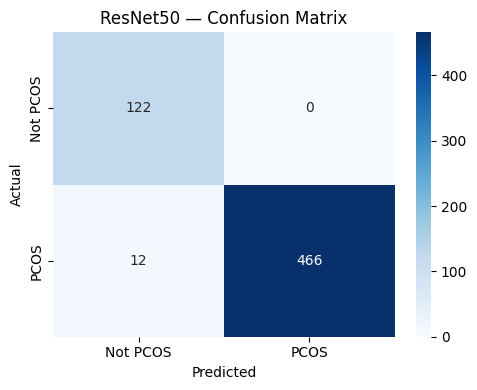

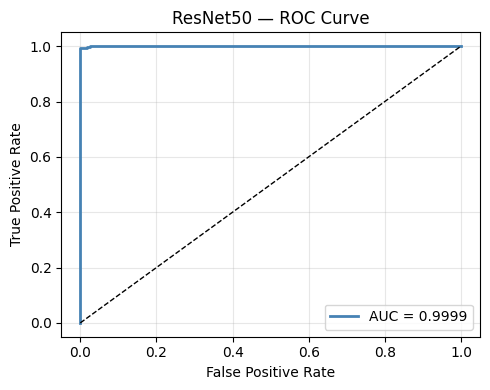

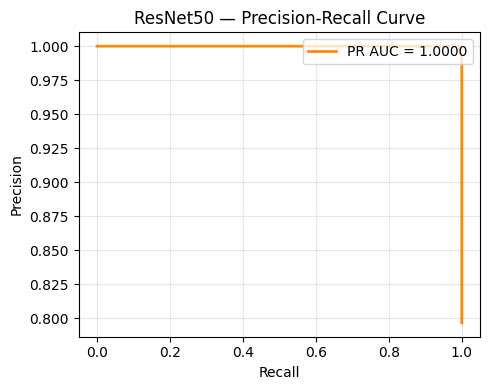

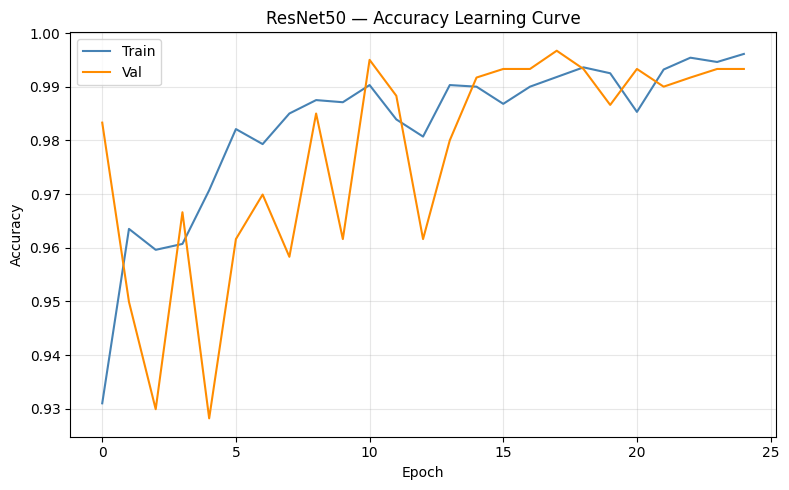

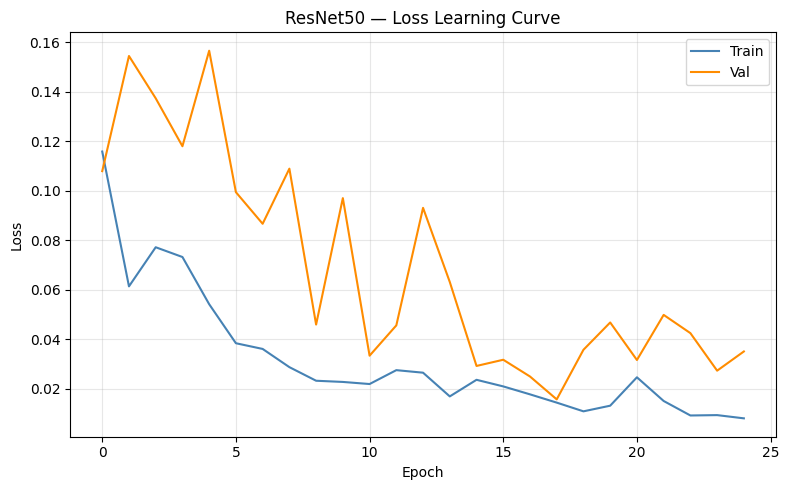

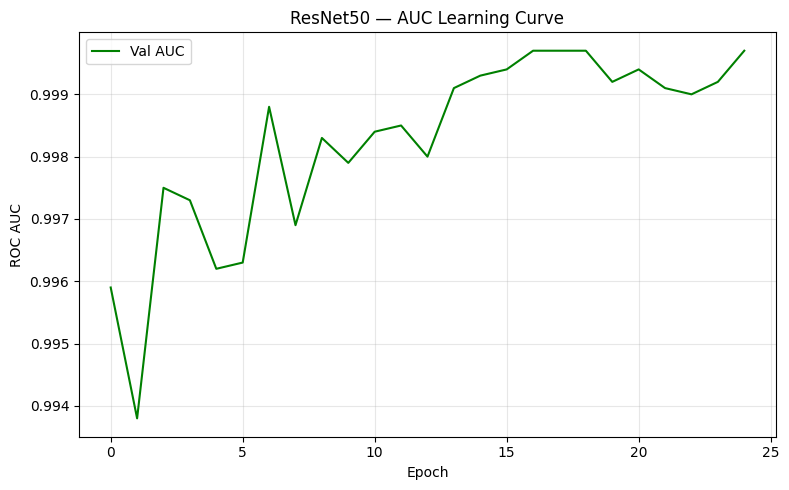


✅ ResNet50 — COMPLETE. All results saved to Drive.
   📁 /content/drive/MyDrive/PCOS_Image_Results2/ResNet50
✅ ResNet50 DONE — proceed to Model 2


In [ ]:
# =============================================================================
#
#  ██████╗ ███████╗███████╗███╗   ██╗███████╗████████╗███████╗ ██████╗
#  ██╔══██╗██╔════╝██╔════╝████╗  ██║██╔════╝╚══██╔══╝██╔════╝██╔═████╗
#  ██████╔╝█████╗  ███████╗██╔██╗ ██║█████╗     ██║   ███████╗██║██╔██║
#  ██╔══██╗██╔══╝  ╚════██║██║╚██╗██║██╔══╝     ██║   ╚════██║████╔╝██║
#  ██║  ██║███████╗███████║██║ ╚████║███████╗   ██║   ███████║╚██████╔╝
#  ╚═╝  ╚═╝╚══════╝╚══════╝╚═╝  ╚═══╝╚══════╝   ╚═╝   ╚══════╝ ╚═════╝
#                          R E S N E T 5 0
#
# =============================================================================

# ─────────────────────────────────────────────────────────────────────────────
# MODEL 1 ▸ ResNet50  — TRAIN + EVALUATE + SAVE
# ─────────────────────────────────────────────────────────────────────────────
set_seed(SEED)
resnet = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
resnet.fc = nn.Linear(resnet.fc.in_features, 2)

train_model("ResNet50", resnet)

print("✅ ResNet50 DONE — proceed to Model 2")



  TRAINING : EfficientNetB0


Epoch 1/30: 100%|██████████| 88/88 [00:30<00:00,  2.87it/s]


   Epoch 01 | TrainLoss 0.2107 | ValLoss 0.1833 | ValAcc 0.9599 | ValAUC 0.9970
   ✅ Best model saved (AUC=0.9970, Epoch=1)


Epoch 2/30: 100%|██████████| 88/88 [00:32<00:00,  2.72it/s]


   Epoch 02 | TrainLoss 0.0730 | ValLoss 0.1362 | ValAcc 0.9533 | ValAUC 0.9964


...

   Epoch 28 | TrainLoss 0.0120 | ValLoss 0.0273 | ValAcc 0.9933 | ValAUC 0.9993


Epoch 29/30: 100%|██████████| 88/88 [00:34<00:00,  2.57it/s]


   Epoch 29 | TrainLoss 0.0137 | ValLoss 0.0363 | ValAcc 0.9900 | ValAUC 0.9995


Epoch 30/30: 100%|██████████| 88/88 [00:33<00:00,  2.64it/s]


   Epoch 30 | TrainLoss 0.0127 | ValLoss 0.0352 | ValAcc 0.9933 | ValAUC 0.9995

   📄 Training log saved (best epoch: 25)
   ✅ Best model loaded for test evaluation

   Evaluating on test set...

─────────────────────────────────────────────
  TEST RESULTS : EfficientNetB0
─────────────────────────────────────────────
  accuracy                  : 0.9883
  precision                 : 0.9958
  recall_sensitivity        : 0.9895
  specificity               : 0.9836
  f1_score                  : 0.9927
  roc_auc                   : 0.9993
  pr_auc                    : 0.9998
  mcc                       : 0.9644
  log_loss                  : 0.0410


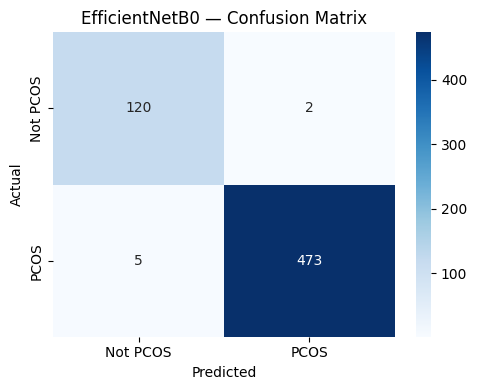

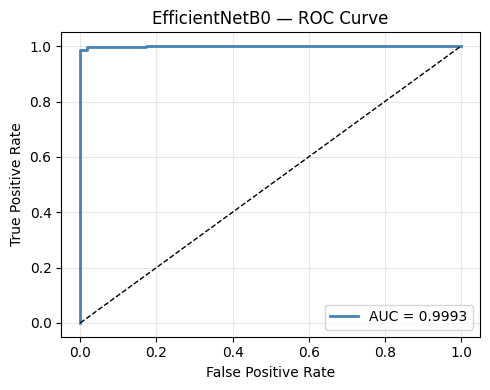

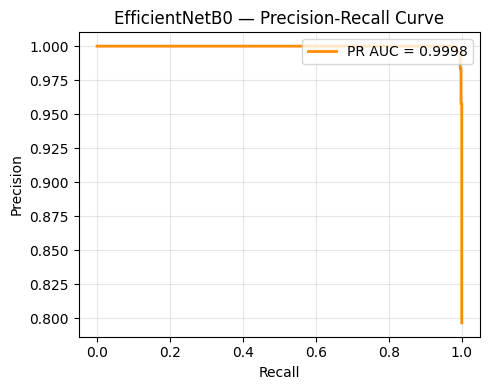

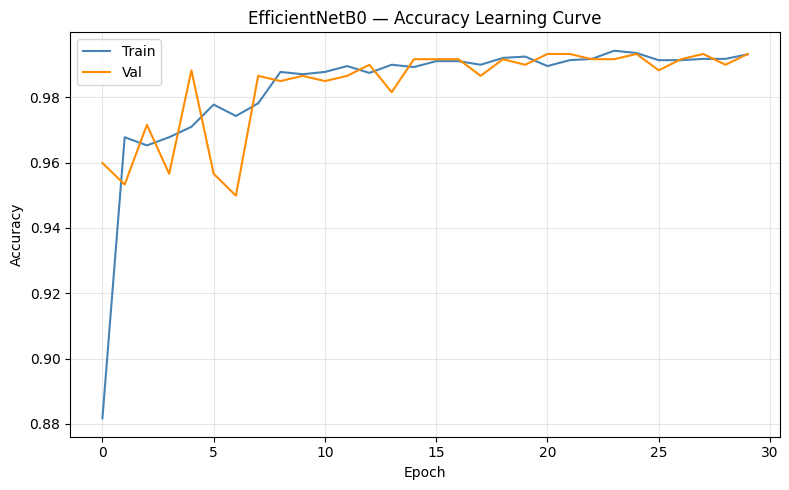

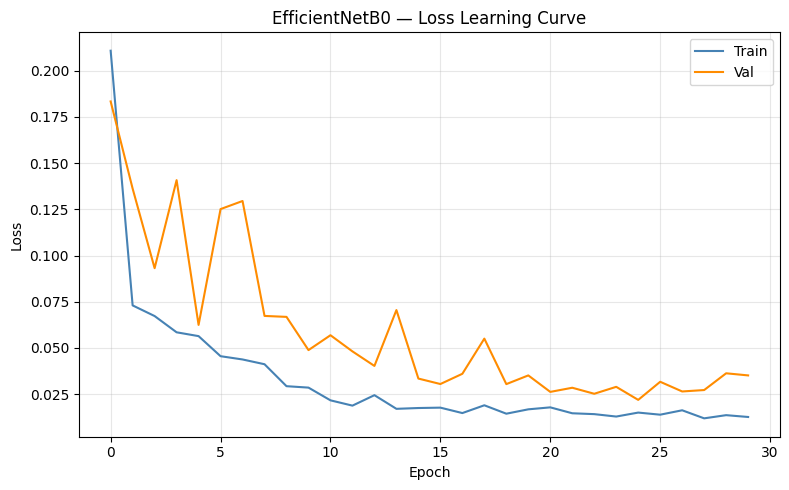

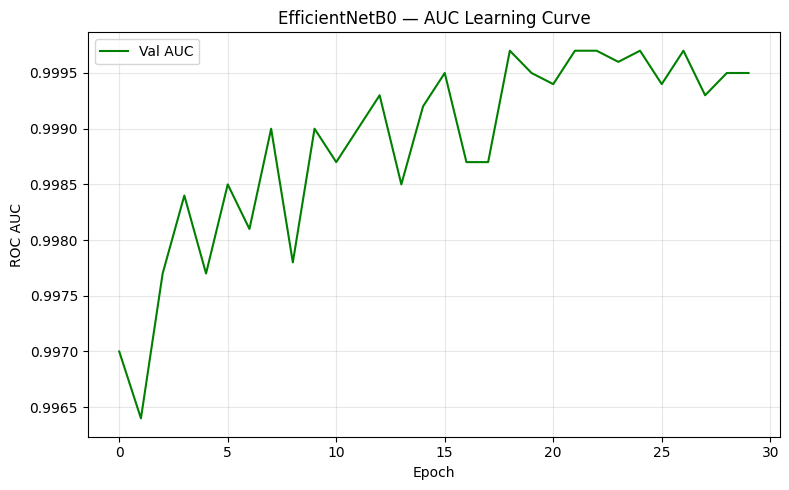


✅ EfficientNetB0 — COMPLETE. All results saved to Drive.
   📁 /content/drive/MyDrive/PCOS_Image_Results2/EfficientNetB0
✅ EfficientNetB0 DONE — proceed to Model 3


In [ ]:
# =============================================================================
#
#  ███████╗███████╗███████╗██╗ ██████╗██╗███████╗███╗   ██╗████████╗
#  ██╔════╝██╔════╝██╔════╝██║██╔════╝██║██╔════╝████╗  ██║╚══██╔══╝
#  █████╗  █████╗  █████╗  ██║██║     ██║█████╗  ██╔██╗ ██║   ██║
#  ██╔══╝  ██╔══╝  ██╔══╝  ██║██║     ██║██╔══╝  ██║╚██╗██║   ██║
#  ███████╗██║     ██║     ██║╚██████╗██║███████╗██║ ╚████║   ██║
#  ╚══════╝╚═╝     ╚═╝     ╚═╝ ╚═════╝╚═╝╚══════╝╚═╝  ╚═══╝   ╚═╝
#                     E F F I C I E N T N E T B 0
#
# =============================================================================

# ─────────────────────────────────────────────────────────────────────────────
# MODEL 2 ▸ EfficientNetB0 — TRAIN + EVALUATE + SAVE
# ─────────────────────────────────────────────────────────────────────────────
set_seed(SEED)
efficientnet = models.efficientnet_b0(
    weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1
)
# EfficientNet classifier is Sequential — replace last Linear layer
in_features = efficientnet.classifier[1].in_features
efficientnet.classifier[1] = nn.Linear(in_features, 2)

train_model("EfficientNetB0", efficientnet)

print("✅ EfficientNetB0 DONE — proceed to Model 3")



  TRAINING : DenseNet121


Epoch 1/30: 100%|██████████| 88/88 [00:39<00:00,  2.20it/s]


   Epoch 01 | TrainLoss 0.1559 | ValLoss 0.1074 | ValAcc 0.9649 | ValAUC 0.9955
   ✅ Best model saved (AUC=0.9955, Epoch=1)


Epoch 2/30: 100%|██████████| 88/88 [00:43<00:00,  2.02it/s]


   Epoch 02 | TrainLoss 0.0666 | ValLoss 0.0966 | ValAcc 0.9666 | ValAUC 0.9941


...

   Epoch 28 | TrainLoss 0.0081 | ValLoss 0.0180 | ValAcc 0.9967 | ValAUC 0.9998


Epoch 29/30: 100%|██████████| 88/88 [00:34<00:00,  2.54it/s]


   Epoch 29 | TrainLoss 0.0074 | ValLoss 0.0193 | ValAcc 0.9967 | ValAUC 0.9997


Epoch 30/30: 100%|██████████| 88/88 [00:35<00:00,  2.48it/s]


   Epoch 30 | TrainLoss 0.0086 | ValLoss 0.0191 | ValAcc 0.9967 | ValAUC 0.9998
   ⛔ Early stopping triggered (patience=7)

   📄 Training log saved (best epoch: 23)
   ✅ Best model loaded for test evaluation

   Evaluating on test set...

─────────────────────────────────────────────
  TEST RESULTS : DenseNet121
─────────────────────────────────────────────
  accuracy                  : 0.9883
  precision                 : 0.9979
  recall_sensitivity        : 0.9874
  specificity               : 0.9918
  f1_score                  : 0.9926
  roc_auc                   : 0.9994
  pr_auc                    : 0.9998
  mcc                       : 0.9648
  log_loss                  : 0.0357


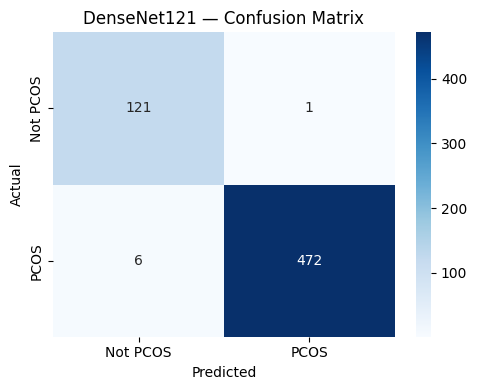

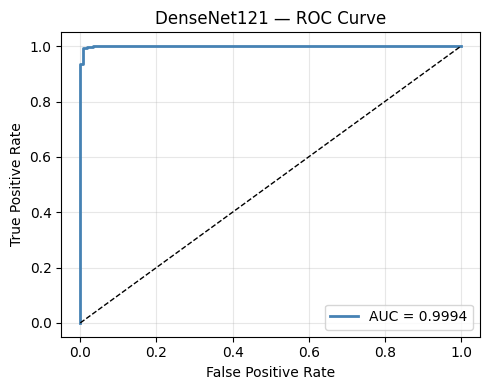

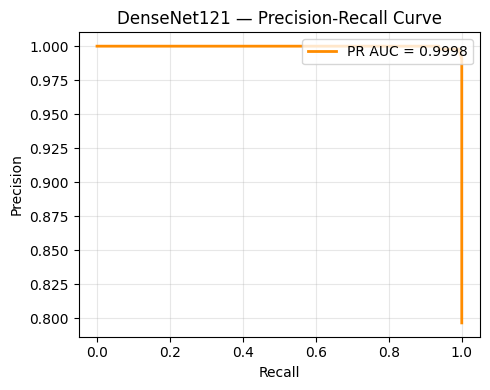

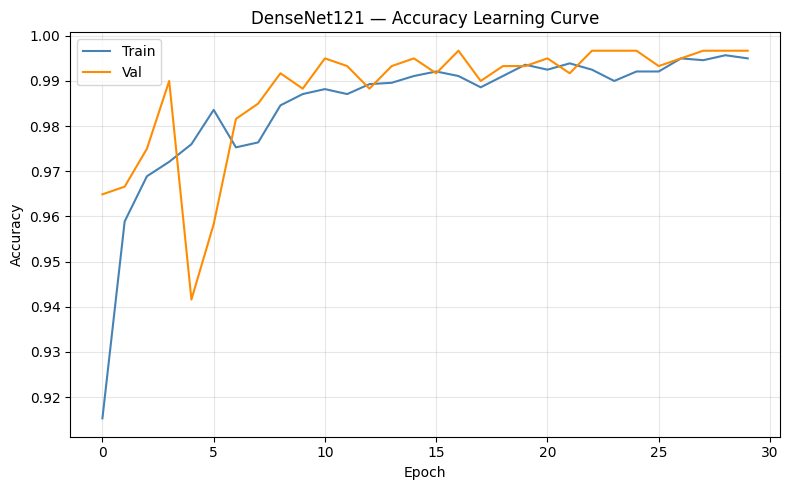

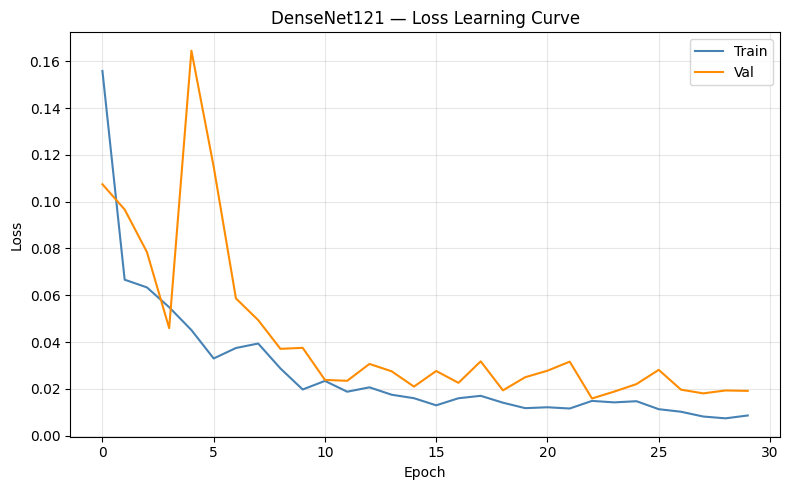

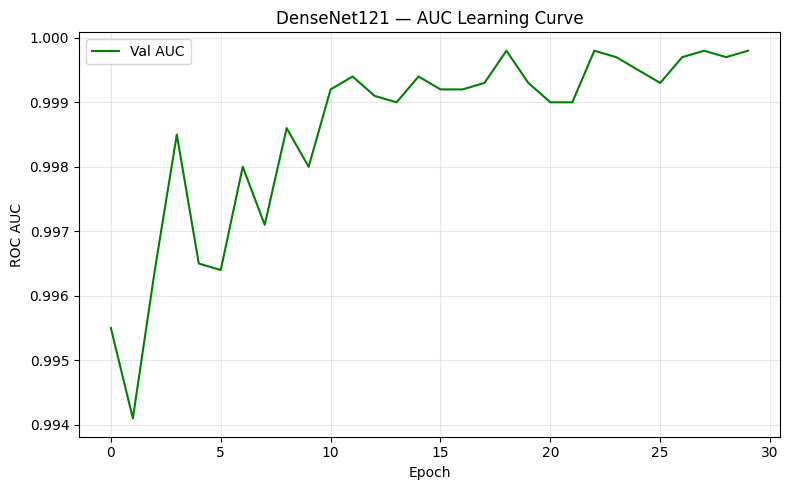


✅ DenseNet121 — COMPLETE. All results saved to Drive.
   📁 /content/drive/MyDrive/PCOS_Image_Results2/DenseNet121
✅ DenseNet121 DONE — proceed to Model 4


In [ ]:

# =============================================================================
#
#  ██████╗ ███████╗███╗   ██╗███████╗███████╗███╗   ██╗███████╗████████╗
#  ██╔══██╗██╔════╝████╗  ██║██╔════╝██╔════╝████╗  ██║██╔════╝╚══██╔══╝
#  ██║  ██║█████╗  ██╔██╗ ██║███████╗█████╗  ██╔██╗ ██║█████╗     ██║
#  ██║  ██║██╔══╝  ██║╚██╗██║╚════██║██╔══╝  ██║╚██╗██║██╔══╝     ██║
#  ██████╔╝███████╗██║ ╚████║███████║███████╗██║ ╚████║███████╗   ██║
#  ╚═════╝ ╚══════╝╚═╝  ╚═══╝╚══════╝╚══════╝╚═╝  ╚═══╝╚══════╝   ╚═╝
#                       D E N S E N E T 1 2 1
#
# =============================================================================

# ─────────────────────────────────────────────────────────────────────────────
# MODEL 3 ▸ DenseNet121 — TRAIN + EVALUATE + SAVE
# ─────────────────────────────────────────────────────────────────────────────
set_seed(SEED)
densenet = models.densenet121(
    weights=models.DenseNet121_Weights.IMAGENET1K_V1
)
densenet.classifier = nn.Linear(densenet.classifier.in_features, 2)

train_model("DenseNet121", densenet)

print("✅ DenseNet121 DONE — proceed to Model 4")




  TRAINING : MobileNetV2


Epoch 1/30: 100%|██████████| 88/88 [00:29<00:00,  3.02it/s]


   Epoch 01 | TrainLoss 0.1461 | ValLoss 0.1102 | ValAcc 0.9716 | ValAUC 0.9944
   ✅ Best model saved (AUC=0.9944, Epoch=1)


Epoch 2/30: 100%|██████████| 88/88 [00:29<00:00,  2.97it/s]


   Epoch 02 | TrainLoss 0.0730 | ValLoss 0.0582 | ValAcc 0.9933 | ValAUC 0.9979
   ✅ Best model saved (AUC=0.9979, Epoch=2)


...

   Epoch 15 | TrainLoss 0.0155 | ValLoss 0.0666 | ValAcc 0.9766 | ValAUC 0.9989


Epoch 16/30: 100%|██████████| 88/88 [00:34<00:00,  2.57it/s]


   Epoch 16 | TrainLoss 0.0153 | ValLoss 0.0449 | ValAcc 0.9850 | ValAUC 0.9988


Epoch 17/30: 100%|██████████| 88/88 [00:33<00:00,  2.66it/s]


   Epoch 17 | TrainLoss 0.0109 | ValLoss 0.0451 | ValAcc 0.9866 | ValAUC 0.9991
   ⛔ Early stopping triggered (patience=7)

   📄 Training log saved (best epoch: 12)
   ✅ Best model loaded for test evaluation

   Evaluating on test set...

─────────────────────────────────────────────
  TEST RESULTS : MobileNetV2
─────────────────────────────────────────────
  accuracy                  : 0.9833
  precision                 : 1.0000
  recall_sensitivity        : 0.9791
  specificity               : 1.0000
  f1_score                  : 0.9894
  roc_auc                   : 0.9998
  pr_auc                    : 1.0000
  mcc                       : 0.9513
  log_loss                  : 0.0522


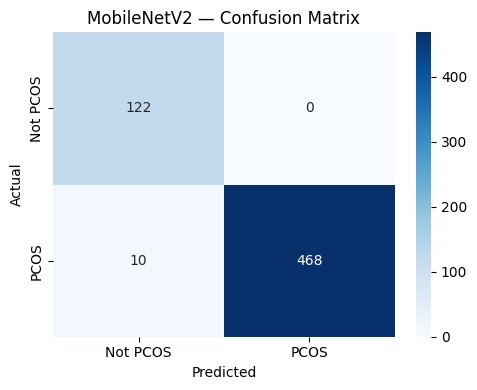

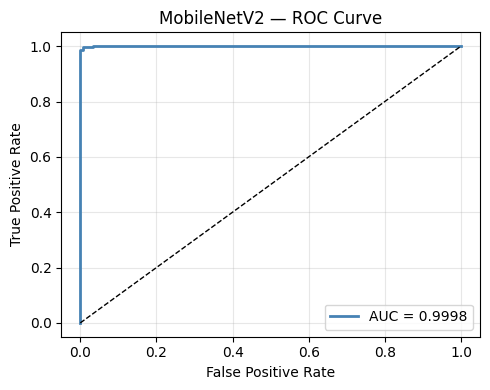

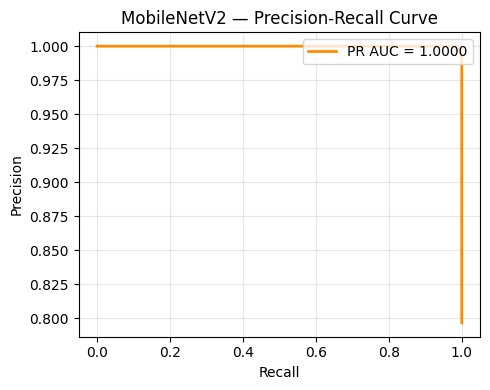

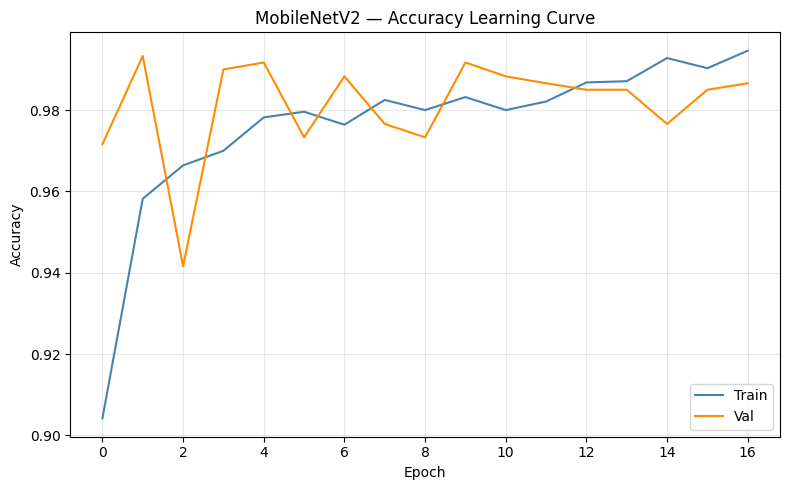

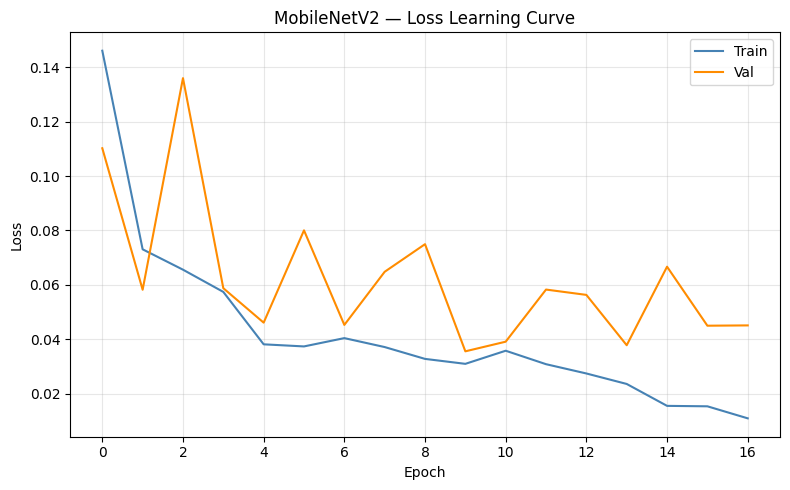

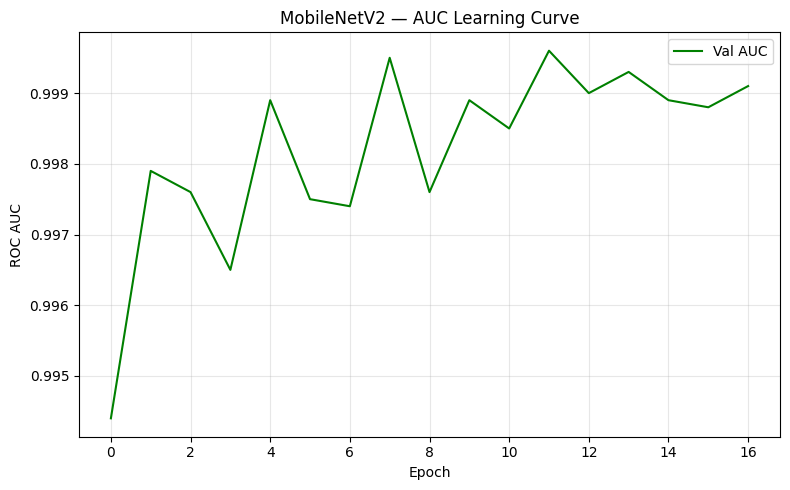


✅ MobileNetV2 — COMPLETE. All results saved to Drive.
   📁 /content/drive/MyDrive/PCOS_Image_Results2/MobileNetV2
✅ MobileNetV2 DONE


In [ ]:
# =============================================================================
#
#  ███╗   ███╗ ██████╗ ██████╗ ██╗██╗     ███████╗███╗   ██╗███████╗████████╗
#  ████╗ ████║██╔═══██╗██╔══██╗██║██║     ██╔════╝████╗  ██║██╔════╝╚══██╔══╝
#  ██╔████╔██║██║   ██║██████╔╝██║██║     █████╗  ██╔██╗ ██║█████╗     ██║
#  ██║╚██╔╝██║██║   ██║██╔══██╗██║██║     ██╔══╝  ██║╚██╗██║██╔══╝     ██║
#  ██║ ╚═╝ ██║╚██████╔╝██████╔╝██║███████╗███████╗██║ ╚████║███████╗   ██║
#  ╚═╝     ╚═╝ ╚═════╝ ╚═════╝ ╚═╝╚══════╝╚══════╝╚═╝  ╚═══╝╚══════╝   ╚═╝
#                        M O B I L E N E T V 2
#
# =============================================================================

# ─────────────────────────────────────────────────────────────────────────────
# MODEL 4 ▸ MobileNetV2 — TRAIN + EVALUATE + SAVE
# ─────────────────────────────────────────────────────────────────────────────
set_seed(SEED)
mobilenet = models.mobilenet_v2(
    weights=models.MobileNet_V2_Weights.IMAGENET1K_V1
)
# MobileNetV2 classifier is Sequential[Dropout, Linear] — replace Linear
mobilenet.classifier[1] = nn.Linear(mobilenet.classifier[1].in_features, 2)

train_model("MobileNetV2", mobilenet)

print("✅ MobileNetV2 DONE")

In [ ]:
# RECOVERY CELL — run only if runtime restarted
import os, json
import pandas as pd

model_results = []
for model_name in ["ResNet50", "EfficientNetB0", "DenseNet121", "MobileNetV2"]:
    path = f"/content/drive/MyDrive/PCOS_Image_Results2/{model_name}/test_metrics.json"
    if os.path.exists(path):
        with open(path) as f:
            m = json.load(f)
        m["Model"] = model_name
        model_results.append(m)
        print(f"✅ Loaded {model_name}")
    else:
        print(f"❌ Missing {model_name}")

print(f"\nTotal models loaded: {len(model_results)}")

✅ Loaded ResNet50
✅ Loaded EfficientNetB0
✅ Loaded DenseNet121
✅ Loaded MobileNetV2

Total models loaded: 4



  FINAL COMPARISON — ALL MODELS
Columns: ['Accuracy', 'Precision', 'Sensitivity', 'Specificity', 'F1 Score', 'ROC AUC', 'PR AUC', 'MCC', 'Log Loss', 'Model']
         Model  Accuracy  Precision  Sensitivity  Specificity  F1 Score  ROC AUC  PR AUC    MCC  Log Loss
      ResNet50    0.9800     1.0000       0.9749       1.0000    0.9873   0.9999  1.0000 0.9421    0.0623
EfficientNetB0    0.9883     0.9958       0.9895       0.9836    0.9927   0.9993  0.9998 0.9644    0.0410
   DenseNet121    0.9883     0.9979       0.9874       0.9918    0.9926   0.9994  0.9998 0.9648    0.0357
   MobileNetV2    0.9833     1.0000       0.9791       1.0000    0.9894   0.9998  1.0000 0.9513    0.0522

✅ Comparison table saved → /content/drive/MyDrive/PCOS_Image_Results2/model_comparison.csv


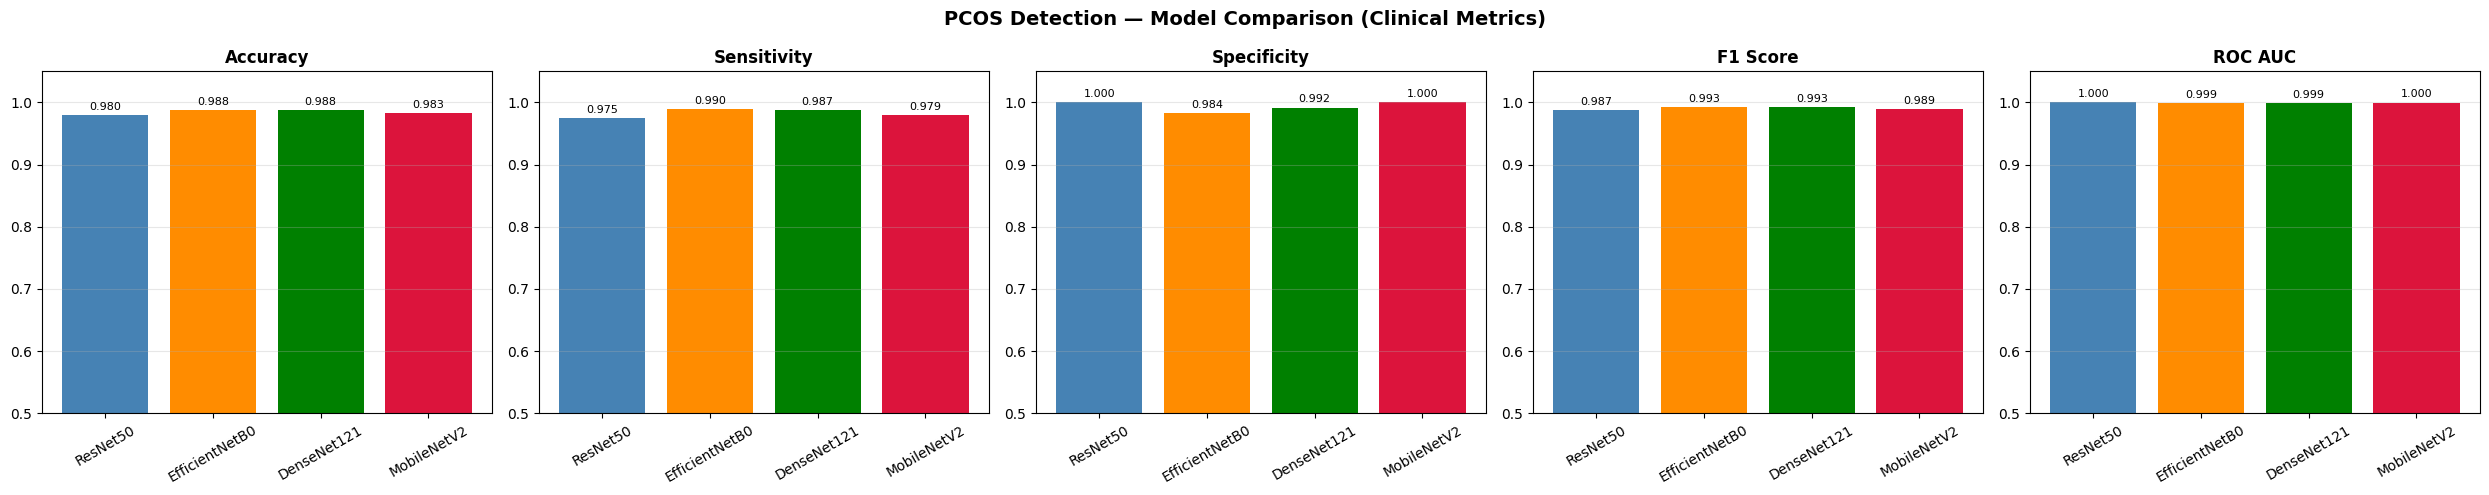


🎉 ALL 4 MODELS COMPLETE!
📁 Everything saved → /content/drive/MyDrive/PCOS_Image_Results2

Output per model:
  best_model.pth          — best checkpoint (restorable)
  test_metrics.json       — all test metrics
  training_log.csv        — epoch-wise full metric history
  best_epoch_info.json    — best epoch + best AUC
  confusion_matrix.png
  roc_curve.png
  pr_curve.png
  learning_curve_accuracy.png
  learning_curve_loss.png
  learning_curve_auc.png


In [ ]:
# =============================================================================
# FINAL BLOCK ▸ MODEL COMPARISON TABLE
# Run after ALL 5 models are trained
# =============================================================================

print("\n" + "=" * 70)
print("  FINAL COMPARISON — ALL MODELS")
print("=" * 70)

comparison_df = pd.DataFrame(model_results)

# ── Fix column names ──────────────────────────────────────────────────────────
comparison_df = comparison_df.rename(columns={
    "accuracy"           : "Accuracy",
    "precision"          : "Precision",
    "recall_sensitivity" : "Sensitivity",
    "specificity"        : "Specificity",
    "f1_score"           : "F1 Score",
    "roc_auc"            : "ROC AUC",
    "pr_auc"             : "PR AUC",
    "mcc"                : "MCC",
    "log_loss"           : "Log Loss"
})

# ── Debug: see exact column names ────────────────────────────────────────────
print("Columns:", comparison_df.columns.tolist())

# ── Model column first (safe — only use columns that exist) ──────────────────
desired = ["Model", "Accuracy", "Precision", "Sensitivity", "Specificity",
           "F1 Score", "ROC AUC", "PR AUC", "MCC", "Log Loss"]
cols    = [c for c in desired if c in comparison_df.columns]
comparison_df = comparison_df[cols]

print(comparison_df.to_string(index=False))

# Save CSV
comparison_df.to_csv(
    os.path.join(RESULT_DIR, "model_comparison.csv"), index=False
)
print(f"\n✅ Comparison table saved → {RESULT_DIR}/model_comparison.csv")

# ── Bar chart comparison ──────────────────────────────────────────────────────
metrics_to_plot = ["Accuracy", "Sensitivity", "Specificity", "F1 Score", "ROC AUC"]
colors          = ["steelblue", "darkorange", "green", "crimson", "purple"]

fig, axes = plt.subplots(1, len(metrics_to_plot), figsize=(25, 5))

for i, metric in enumerate(metrics_to_plot):
    bars = axes[i].bar(comparison_df["Model"], comparison_df[metric],
                       color=colors)
    axes[i].set_title(metric, fontsize=12, fontweight="bold")
    axes[i].set_ylim(0.5, 1.05)
    axes[i].tick_params(axis="x", rotation=30)
    axes[i].grid(axis="y", alpha=0.3)
    for bar, val in zip(bars, comparison_df[metric]):
        axes[i].text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.005,
            f"{val:.3f}", ha="center", va="bottom", fontsize=8
        )

plt.suptitle("PCOS Detection — Model Comparison (Clinical Metrics)",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(RESULT_DIR, "model_comparison_chart.png"), dpi=150)
plt.show()
plt.close()

print("\n🎉 ALL 4 MODELS COMPLETE!")
print(f"📁 Everything saved → {RESULT_DIR}")
print("\nOutput per model:")
print("  best_model.pth          — best checkpoint (restorable)")
print("  test_metrics.json       — all test metrics")
print("  training_log.csv        — epoch-wise full metric history")
print("  best_epoch_info.json    — best epoch + best AUC")
print("  confusion_matrix.png")
print("  roc_curve.png")
print("  pr_curve.png")
print("  learning_curve_accuracy.png")
print("  learning_curve_loss.png")
print("  learning_curve_auc.png")

In [ ]:
# =============================================================================
# PCOS — STEP 1 : RISK SCORE CALCULATOR
# Best Model : DenseNet121
# Input      : Single ultrasound image
# Output     : Risk probability + Risk category + Clinical recommendation
# =============================================================================

# ─────────────────────────────────────────────────────────────────────────────
# BLOCK 1 ▸ MOUNT
# ─────────────────────────────────────────────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')



Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# BLOCK 2 ▸ IMPORTS
# ─────────────────────────────────────────────────────────────────────────────
import os
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from torchvision import models, transforms
from PIL import Image

print("✅ Imports done")



✅ Imports done


In [ ]:

# ─────────────────────────────────────────────────────────────────────────────
# BLOCK 3 ▸ CONFIG
# ─────────────────────────────────────────────────────────────────────────────
MODEL_PATH  = "/content/drive/MyDrive/PCOS_Image_Results2/DenseNet121/best_model.pth"
RESULT_DIR  = "/content/drive/MyDrive/PCOS_Image_Results2/RiskScore"
os.makedirs(RESULT_DIR, exist_ok=True)

DEVICE   = torch.device("cuda" if torch.cuda.is_available() else "cpu")
IMG_SIZE = 224

# ── Risk thresholds (clinical) ────────────────────────────────────────────────
# Based on EfficientNetB0 output probability for PCOS class
THRESHOLDS = {
    "low"    : (0.00, 0.33),   #  0–33%  → Low risk
    "medium" : (0.33, 0.66),   # 33–66%  → Medium risk — monitor
    "high"   : (0.66, 1.00),   # 66–100% → High risk   — clinical review
}

print("✅ Config ready")
print(f"   Device     : {DEVICE}")
print(f"   Model path : {MODEL_PATH}")


✅ Config ready
   Device     : cuda
   Model path : /content/drive/MyDrive/PCOS_Image_Results2/DenseNet121/best_model.pth


In [ ]:

# ─────────────────────────────────────────────────────────────────────────────
# BLOCK 4 ▸ LOAD MODEL
# ─────────────────────────────────────────────────────────────────────────────
def load_model():
    model = models.densenet121(
        weights=None
    )
    in_features = model.classifier.in_features
    model.classifier = nn.Linear(in_features, 2)   # ← DenseNet uses model.classifier directly, not classifier[1]

    checkpoint = torch.load(MODEL_PATH, map_location=DEVICE, weights_only=False)
    model.load_state_dict(checkpoint["model_state"])
    model.eval()
    model = model.to(DEVICE)

    print(f"✅ DenseNet121 loaded")
    print(f"   Best epoch : {checkpoint['epoch']}")
    print(f"   Val AUC    : {checkpoint['val_auc']:.4f}")
    print(f"   Val Acc    : {checkpoint['val_acc']:.4f}")

    return model
model = load_model()

✅ DenseNet121 loaded
   Best epoch : 23
   Val AUC    : 0.9998
   Val Acc    : 0.9967


In [ ]:

# ─────────────────────────────────────────────────────────────────────────────
# BLOCK 5 ▸ PREPROCESSING TRANSFORM
# ─────────────────────────────────────────────────────────────────────────────
preprocess = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std =[0.229, 0.224, 0.225]
    )
])

print("✅ Preprocessing transform ready")



✅ Preprocessing transform ready


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# BLOCK 6 ▸ RISK SCORE FUNCTION
# ─────────────────────────────────────────────────────────────────────────────
def compute_risk_score(image_path):
    """
    Given an ultrasound image path:
    1. Preprocess the image
    2. Run EfficientNetB0 inference
    3. Return probability, risk category, recommendation

    Returns dict with full risk profile.
    """
    # Load and preprocess
    img = Image.open(image_path).convert("RGB")
    tensor = preprocess(img).unsqueeze(0).to(DEVICE)

    # Inference
    with torch.no_grad():
        out   = model(tensor)
        probs = torch.softmax(out, dim=1)[0]

    prob_not_pcos = probs[0].item()
    prob_pcos     = probs[1].item()
    risk_score    = round(prob_pcos * 100, 2)   # as percentage

    # Risk category
    if prob_pcos < 0.33:
        category       = "LOW RISK"
        color          = "green"
        recommendation = "No immediate concern. Routine follow-up recommended."
    elif prob_pcos < 0.66:
        category       = "MEDIUM RISK"
        color          = "orange"
        recommendation = "Borderline findings. Clinical correlation and repeat scan advised."
    else:
        category       = "HIGH RISK"
        color          = "red"
        recommendation = "High likelihood of PCOS. Immediate clinical review recommended."

    return {
        "image_path"      : image_path,
        "prob_pcos"       : round(prob_pcos, 4),
        "prob_not_pcos"   : round(prob_not_pcos, 4),
        "risk_score_pct"  : risk_score,
        "risk_category"   : category,
        "color"           : color,
        "recommendation"  : recommendation
    }

print("✅ compute_risk_score() ready")


✅ compute_risk_score() ready


In [ ]:

# ─────────────────────────────────────────────────────────────────────────────
# BLOCK 7 ▸ RISK REPORT PLOT
# ─────────────────────────────────────────────────────────────────────────────
def plot_risk_report(result, save_path=None):
    """
    Generates a clinical-style risk report card showing:
    - Original image
    - Probability bar chart
    - Risk gauge
    - Recommendation
    """
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    fig.patch.set_facecolor("#f8f9fa")

    # ── Panel 1: Original image ───────────────────────────────────────────────
    img = Image.open(result["image_path"]).convert("RGB")
    axes[0].imshow(img)
    axes[0].set_title("Ultrasound Image", fontsize=13, fontweight="bold")
    axes[0].axis("off")


    # ── Panel 2: Probability bar ──────────────────────────────────────────────
    labels = ["Not PCOS", "PCOS"]
    probs  = [result["prob_not_pcos"], result["prob_pcos"]]
    colors = ["steelblue", result["color"]]
    bars   = axes[1].bar(labels, probs, color=colors, edgecolor="white", linewidth=1.5)
    axes[1].set_ylim(0, 1.15)
    axes[1].set_ylabel("Probability", fontsize=11)
    axes[1].set_title("Model Confidence", fontsize=13, fontweight="bold")
    axes[1].grid(axis="y", alpha=0.3)
    for bar, val in zip(bars, probs):
        axes[1].text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.02,
            f"{val*100:.2f}%",           # ← was :.1f  now :.2f
            ha="center", va="bottom", fontsize=12, fontweight="bold"
        )

    # ── Panel 3: Risk report card ─────────────────────────────────────────────
    axes[2].axis("off")
    axes[2].set_facecolor("#ffffff")

    # Risk score circle
    circle = plt.Circle((0.5, 0.72), 0.18, color=result["color"], alpha=0.15)
    axes[2].add_patch(circle)
    circle2 = plt.Circle((0.5, 0.72), 0.18, fill=False,
                          color=result["color"], linewidth=3)
    axes[2].add_patch(circle2)
    axes[2].text(0.5, 0.72, f"{result['risk_score_pct']:.2f}%",   # ← was :.1f
                 ha="center", va="center", fontsize=20, fontweight="bold",
                 color=result["color"], transform=axes[2].transAxes)

    axes[2].text(0.5, 0.50, "RISK SCORE",
                 ha="center", fontsize=10, color="gray",
                 transform=axes[2].transAxes)

    axes[2].text(0.5, 0.40, result["risk_category"],
                 ha="center", fontsize=15, fontweight="bold",
                 color=result["color"], transform=axes[2].transAxes)

    # Recommendation box
    axes[2].text(0.5, 0.22,

                 f"Recommendation: {result['recommendation']}",
                 ha="center", va="center", fontsize=9,
                 color="#333333", transform=axes[2].transAxes,
                 wrap=True,
                 bbox=dict(boxstyle="round,pad=0.4", facecolor="#f0f0f0",
                           edgecolor="#cccccc"))

    axes[2].text(0.5, 0.06,
                 "Model: DenseNet121  |  Val AUC: 0.9998",
                 ha="center", fontsize=8, color="gray",
                 transform=axes[2].transAxes)

    plt.suptitle("PCOS Risk Assessment Report",
                 fontsize=15, fontweight="bold", y=1.02)
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
        print(f"   📊 Risk report saved → {save_path}")

    plt.show()
    plt.close()

print("✅ plot_risk_report() ready")


✅ plot_risk_report() ready


In [ ]:

# ─────────────────────────────────────────────────────────────────────────────
# BLOCK 8 ▸ BATCH RISK SCORING (entire test folder)
# ─────────────────────────────────────────────────────────────────────────────
def batch_risk_score(test_dir, save_csv=True):
    """
    Runs risk scoring on ALL images in test_dir (pcos + not_pcos).
    Saves a full CSV with risk scores for every image.
    """
    VALID_EXT = ('.png', '.jpg', '.jpeg')
    records   = []

    for label_folder in ["pcos", "not_pcos"]:
        folder   = os.path.join(test_dir, label_folder)
        true_lbl = 1 if label_folder == "pcos" else 0

        for fname in os.listdir(folder):
            if not fname.lower().endswith(VALID_EXT):
                continue

            fpath  = os.path.join(folder, fname)
            result = compute_risk_score(fpath)

            records.append({
                "filename"       : fname,
                "true_label"     : label_folder,
                "prob_pcos"      : result["prob_pcos"],
                "prob_not_pcos"  : result["prob_not_pcos"],
                "risk_score_pct" : result["risk_score_pct"],
                "risk_category"  : result["risk_category"],
                "correct"        : (result["prob_pcos"] >= 0.5) == (true_lbl == 1)
            })

    df = pd.DataFrame(records)

    # Summary
    print("\n" + "="*50)
    print("BATCH RISK SCORE SUMMARY")
    print("="*50)
    print(f"  Total images   : {len(df)}")
    print(f"  Correct        : {df['correct'].sum()} / {len(df)}")
    print(f"  Accuracy       : {df['correct'].mean():.4f}")
    print(f"\n  Risk distribution:")
    print(df["risk_category"].value_counts().to_string())

    if save_csv:
        csv_path = os.path.join(RESULT_DIR, "batch_risk_scores.csv")
        df.to_csv(csv_path, index=False)
        print(f"\n✅ Batch risk scores saved → {csv_path}")

    return df

print("✅ batch_risk_score() ready")


✅ batch_risk_score() ready


   Sample image : /content/drive/MyDrive/PCOS_Clean_Dataset/test/pcos/70b79aa2f22b08a9d406f0e76ce2988b.jpg

──────────────────────────────────────────────────
  RISK ASSESSMENT RESULT
──────────────────────────────────────────────────
  PCOS Probability : 99.99%
  Risk Score       : 99.99%
  Risk Category    : HIGH RISK
  Recommendation   : High likelihood of PCOS. Immediate clinical review recommended.
──────────────────────────────────────────────────
   📊 Risk report saved → /content/drive/MyDrive/PCOS_Image_Results2/RiskScore/sample_risk_report.png


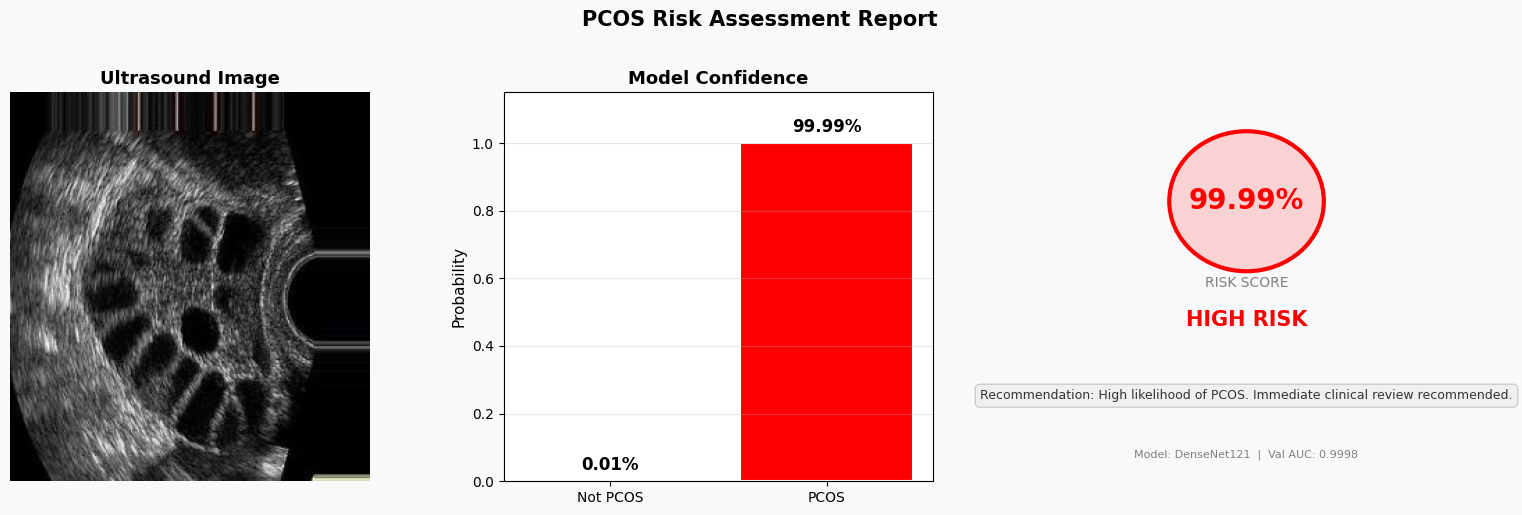

In [ ]:

# ─────────────────────────────────────────────────────────────────────────────
# BLOCK 9 ▸ SINGLE IMAGE DEMO — run on one image
# ─────────────────────────────────────────────────────────────────────────────
# Pick one test image automatically
TEST_DIR   = "/content/drive/MyDrive/PCOS_Clean_Dataset/test"
sample_img = None

for folder in ["pcos", "not_pcos"]:
    fpath = os.path.join(TEST_DIR, folder)
    files = [f for f in os.listdir(fpath) if f.lower().endswith(('.png','.jpg','.jpeg'))]
    if files:
        sample_img = os.path.join(fpath, files[0])
        print(f"   Sample image : {sample_img}")
        break

if sample_img:
    result = compute_risk_score(sample_img)

    print("\n" + "─"*50)
    print("  RISK ASSESSMENT RESULT")
    print("─"*50)
    print(f"  PCOS Probability : {result['prob_pcos']*100:.2f}%")
    print(f"  Risk Score       : {result['risk_score_pct']}%")
    print(f"  Risk Category    : {result['risk_category']}")
    print(f"  Recommendation   : {result['recommendation']}")
    print("─"*50)

    save_path = os.path.join(RESULT_DIR, "sample_risk_report.png")
    plot_risk_report(result, save_path=save_path)


In [ ]:


# ─────────────────────────────────────────────────────────────────────────────
# BLOCK 10 ▸ RUN BATCH SCORING ON ENTIRE TEST SET
# ─────────────────────────────────────────────────────────────────────────────
print("\nRunning batch risk scoring on test set...")
risk_df = batch_risk_score(TEST_DIR)
print(risk_df.head(10).to_string(index=False))


Running batch risk scoring on test set...

BATCH RISK SCORE SUMMARY
  Total images   : 600
  Correct        : 593 / 600
  Accuracy       : 0.9883

  Risk distribution:
risk_category
HIGH RISK      472
LOW RISK       125
MEDIUM RISK      3

✅ Batch risk scores saved → /content/drive/MyDrive/PCOS_Image_Results2/RiskScore/batch_risk_scores.csv
                            filename true_label  prob_pcos  prob_not_pcos  risk_score_pct risk_category  correct
70b79aa2f22b08a9d406f0e76ce2988b.jpg       pcos     0.9999         0.0001           99.99     HIGH RISK     True
d973bcb8314273c4f412c602c86f1742.jpg       pcos     0.9999         0.0001           99.99     HIGH RISK     True
e9edf8fc7f27a4caf2296a0501572fe8.jpg       pcos     1.0000         0.0000          100.00     HIGH RISK     True
11571c56e98bef9922fc55f93703a838.jpg       pcos     0.9996         0.0004           99.96     HIGH RISK     True
38abaf5b35b26ffede1a98788cf3ca1f.jpg       pcos     0.9999         0.0001           99.99  

In [ ]:
# =============================================================================
# PCOS — STEP 2 : EXPLAINABLE AI (Grad-CAM)
# Best Model : EfficientNetB0
# Output     : Heatmap overlaid on ultrasound showing WHERE model looks
# =============================================================================

# ─────────────────────────────────────────────────────────────────────────────
# BLOCK 1 ▸ MOUNT + INSTALL
# ─────────────────────────────────────────────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')



Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# grad-cam library
# !pip install grad-cam -q


# ─────────────────────────────────────────────────────────────────────────────
# BLOCK 2 ▸ IMPORTS
# ─────────────────────────────────────────────────────────────────────────────
import os
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import cv2

from torchvision import models, transforms
from PIL import Image

print("✅ Imports done")



✅ Imports done


In [ ]:

# ─────────────────────────────────────────────────────────────────────────────
# BLOCK 3 ▸ CONFIG
# ─────────────────────────────────────────────────────────────────────────────
MODEL_PATH = "/content/drive/MyDrive/PCOS_Image_Results2/DenseNet121/best_model.pth"
RESULT_DIR = "/content/drive/MyDrive/PCOS_Image_Results2/GradCAM"
TEST_DIR   = "/content/drive/MyDrive/PCOS_Clean_Dataset/test"
os.makedirs(RESULT_DIR, exist_ok=True)

DEVICE   = torch.device("cuda" if torch.cuda.is_available() else "cpu")
IMG_SIZE = 224

print(f"✅ Config ready | Device: {DEVICE}")



✅ Config ready | Device: cuda


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# BLOCK 4 ▸ LOAD MODEL
# ─────────────────────────────────────────────────────────────────────────────
def load_model():
    model = models.densenet121(weights=None)
    in_features = model.classifier.in_features
    model.classifier = nn.Linear(in_features, 2)   # ← same fix

    checkpoint = torch.load(MODEL_PATH, map_location=DEVICE, weights_only=False)
    model.load_state_dict(checkpoint["model_state"])
    model.eval()
    model = model.to(DEVICE)

    print(f"✅ DenseNet121 loaded (Val AUC: {checkpoint['val_auc']:.4f})")
    return model

model = load_model()

✅ DenseNet121 loaded (Val AUC: 0.9998)


In [ ]:

# ─────────────────────────────────────────────────────────────────────────────
# BLOCK 5 ▸ PREPROCESSING
# ─────────────────────────────────────────────────────────────────────────────
preprocess = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std =[0.229, 0.224, 0.225]
    )
])

print("✅ Preprocessing ready")


✅ Preprocessing ready


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# BLOCK 6 ▸ GRAD-CAM IMPLEMENTATION (FIXED)
# ─────────────────────────────────────────────────────────────────────────────
class GradCAM:
    def __init__(self, model, target_layer):
        self.model       = model
        self.gradients   = None
        self.activations = None
        self.fh = target_layer.register_forward_hook(self._save_activation)
        self.bh = target_layer.register_full_backward_hook(self._save_gradient)

    def _save_activation(self, module, input, output):
        self.activations = output.detach()

    def _save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()

    def generate(self, input_tensor, class_idx=1):
        self.model.zero_grad()
        output = self.model(input_tensor)

        if class_idx is None:
            class_idx = output.argmax(dim=1).item()

        output[0, class_idx].backward()

        pooled_grads = self.gradients.mean(dim=[0, 2, 3])
        cam = self.activations[0].clone()
        for i, w in enumerate(pooled_grads):
            cam[i] *= w

        cam = cam.mean(dim=0).cpu().numpy()
        cam = np.maximum(cam, 0)
        if cam.max() > 0:
            cam = cam / cam.max()

        probs     = torch.softmax(output, dim=1)[0].detach().cpu().numpy()
        return cam, class_idx, probs   # ← returns probs directly, not output

    def remove_hooks(self):
        self.fh.remove()
        self.bh.remove()


def get_gradcam_heatmap(image_path, model, class_idx=1):
    img_pil = Image.open(image_path).convert("RGB")
    img_np  = np.array(img_pil.resize((IMG_SIZE, IMG_SIZE)))
    input_t = preprocess(img_pil).unsqueeze(0).to(DEVICE)

    # ── Grad-CAM needs gradients — enable them ────────────────────────────────
    model.eval()
    for param in model.parameters():
        param.requires_grad_(True)

    gcam = GradCAM(model, model.features.denseblock4)   # ← DenseNet121 target layer
    cam, pred_class, probs = gcam.generate(input_t, class_idx=class_idx)
    gcam.remove_hooks()

    cam_resized = cv2.resize(cam, (IMG_SIZE, IMG_SIZE))
    heatmap     = (cm.jet(cam_resized)[:, :, :3] * 255).astype(np.uint8)
    overlay     = (0.5 * img_np + 0.5 * heatmap).astype(np.uint8)

    return {
        "img_pil"      : img_pil,
        "img_np"       : img_np,
        "heatmap"      : heatmap,
        "overlay"      : overlay,
        "cam"          : cam_resized,
        "pred_class"   : pred_class,
        "pred_label"   : "PCOS" if pred_class == 1 else "Not PCOS",
        "prob_pcos"    : round(float(probs[1]), 4),
        "prob_not_pcos": round(float(probs[0]), 4),
    }

print("✅ GradCAM class ready")

✅ GradCAM class ready


In [ ]:

# ─────────────────────────────────────────────────────────────────────────────
# BLOCK 7 ▸ VISUALIZATION FUNCTION
# ─────────────────────────────────────────────────────────────────────────────
def plot_gradcam(result, true_label=None, save_path=None):
    """
    Plots 4-panel Grad-CAM visualization:
    Panel 1: Original image
    Panel 2: Grad-CAM heatmap
    Panel 3: Overlay (heatmap on image)
    Panel 4: Probability bar
    """
    fig, axes = plt.subplots(1, 4, figsize=(20, 5))
    fig.patch.set_facecolor("#f8f9fa")

    pred_color = "red" if result["pred_class"] == 1 else "green"
    pred_label = result["pred_label"]
    prob_pcos  = result["prob_pcos"]

    # Panel 1: Original
    axes[0].imshow(result["img_pil"].resize((IMG_SIZE, IMG_SIZE)))
    axes[0].set_title("Original Image", fontsize=12, fontweight="bold")
    axes[0].axis("off")
    if true_label:
        axes[0].set_xlabel(f"True: {true_label}", fontsize=10, color="blue")

    # Panel 2: Heatmap only
    axes[1].imshow(result["heatmap"])
    axes[1].set_title("Grad-CAM Heatmap", fontsize=12, fontweight="bold")
    axes[1].axis("off")
    axes[1].set_xlabel("Red = High attention region", fontsize=9, color="gray")

    # Panel 3: Overlay
    axes[2].imshow(result["overlay"])
    axes[2].set_title(f"Prediction: {pred_label}\n({prob_pcos*100:.2f}% PCOS)",
                      fontsize=12, fontweight="bold", color=pred_color)
    axes[2].axis("off")

    # Panel 4: Probability bars
    labels = ["Not PCOS", "PCOS"]
    probs  = [result["prob_not_pcos"], result["prob_pcos"]]
    colors = ["steelblue", "crimson"]
    bars   = axes[3].bar(labels, probs, color=colors, edgecolor="white")
    axes[3].set_ylim(0, 1.2)
    axes[3].set_ylabel("Probability", fontsize=11)
    axes[3].set_title("Model Confidence", fontsize=12, fontweight="bold")
    axes[3].grid(axis="y", alpha=0.3)
    for bar, val in zip(bars, probs):
        axes[3].text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.02,
            f"{val*100:.2f}%",
            ha="center", fontsize=12, fontweight="bold"
        )

    plt.suptitle("PCOS Explainability — Grad-CAM Visualization (DenseNet121)",
                 fontsize=14, fontweight="bold", y=1.02)
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
        print(f"   🔍 Grad-CAM saved → {save_path}")

    plt.show()
    plt.close()

print("✅ plot_gradcam() ready")


✅ plot_gradcam() ready



Running Grad-CAM on 4 sample images...

[1/4] PCOS — 70b79aa2f22b08a9d406f0e76ce2988b.jpg
   Prediction : PCOS (99.99% PCOS)
   🔍 Grad-CAM saved → /content/drive/MyDrive/PCOS_Image_Results2/GradCAM/gradcam_PCOS_1.png


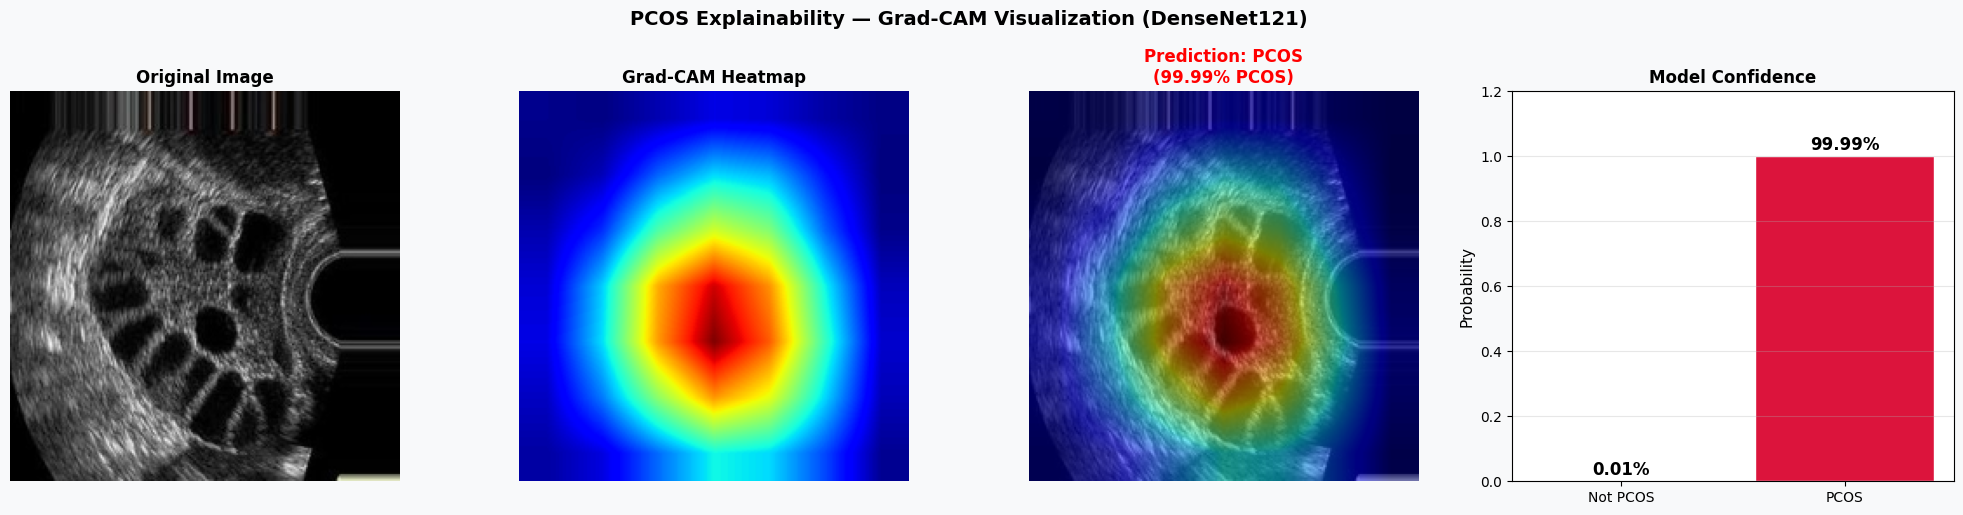


[2/4] PCOS — d973bcb8314273c4f412c602c86f1742.jpg
   Prediction : PCOS (99.99% PCOS)
   🔍 Grad-CAM saved → /content/drive/MyDrive/PCOS_Image_Results2/GradCAM/gradcam_PCOS_2.png


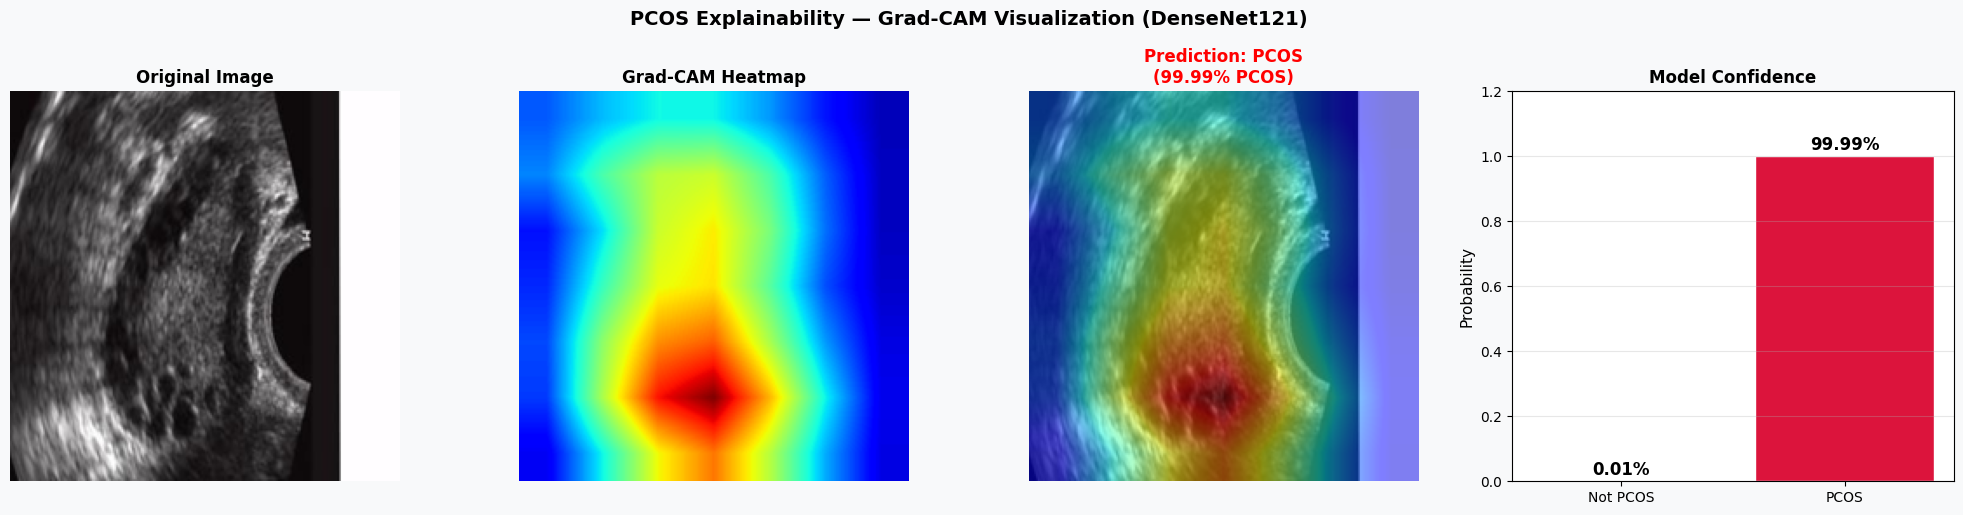


[3/4] Not PCOS — 8551f431c8b07695e5c83906241e85fc.jpg
   Prediction : PCOS (0.13% PCOS)
   🔍 Grad-CAM saved → /content/drive/MyDrive/PCOS_Image_Results2/GradCAM/gradcam_Not_PCOS_3.png


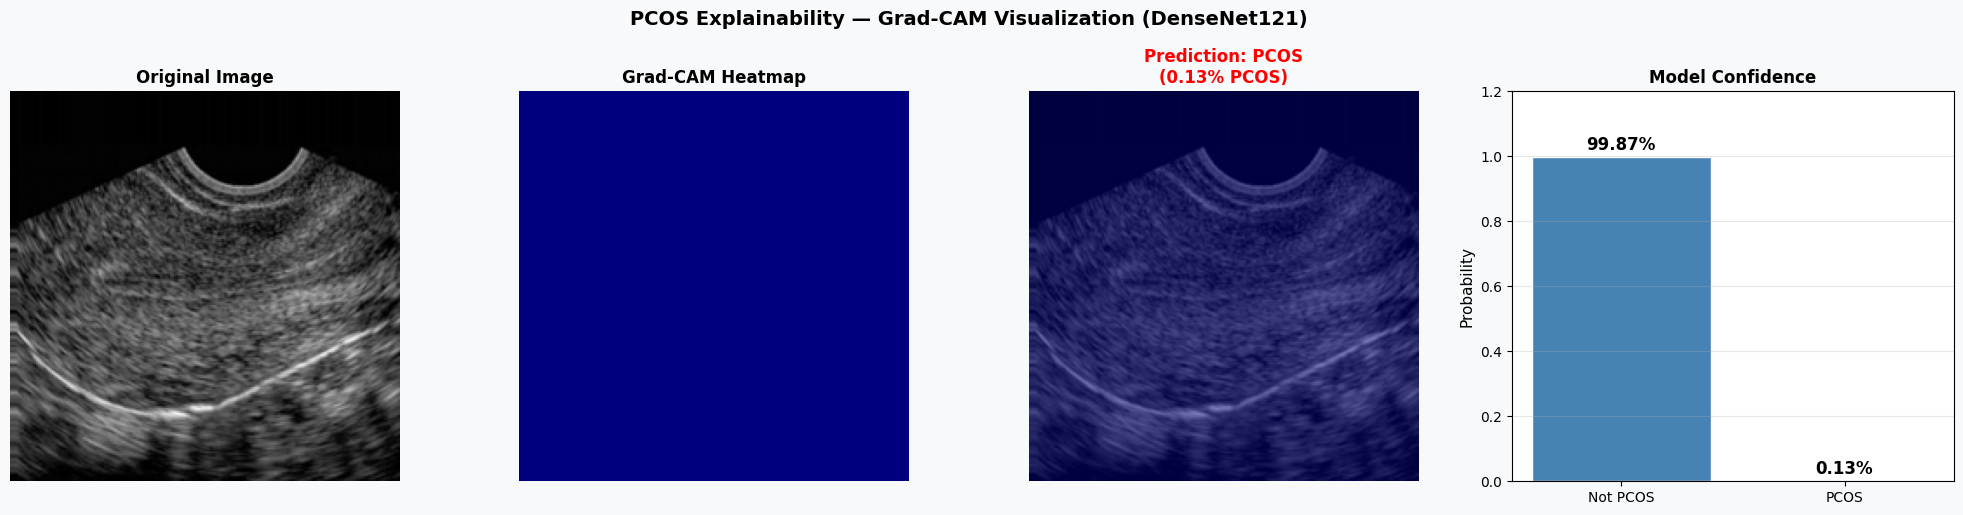


[4/4] Not PCOS — 535c3c6fc9e724dfa7e7f0b74c11320d.jpg
   Prediction : PCOS (0.00% PCOS)
   🔍 Grad-CAM saved → /content/drive/MyDrive/PCOS_Image_Results2/GradCAM/gradcam_Not_PCOS_4.png


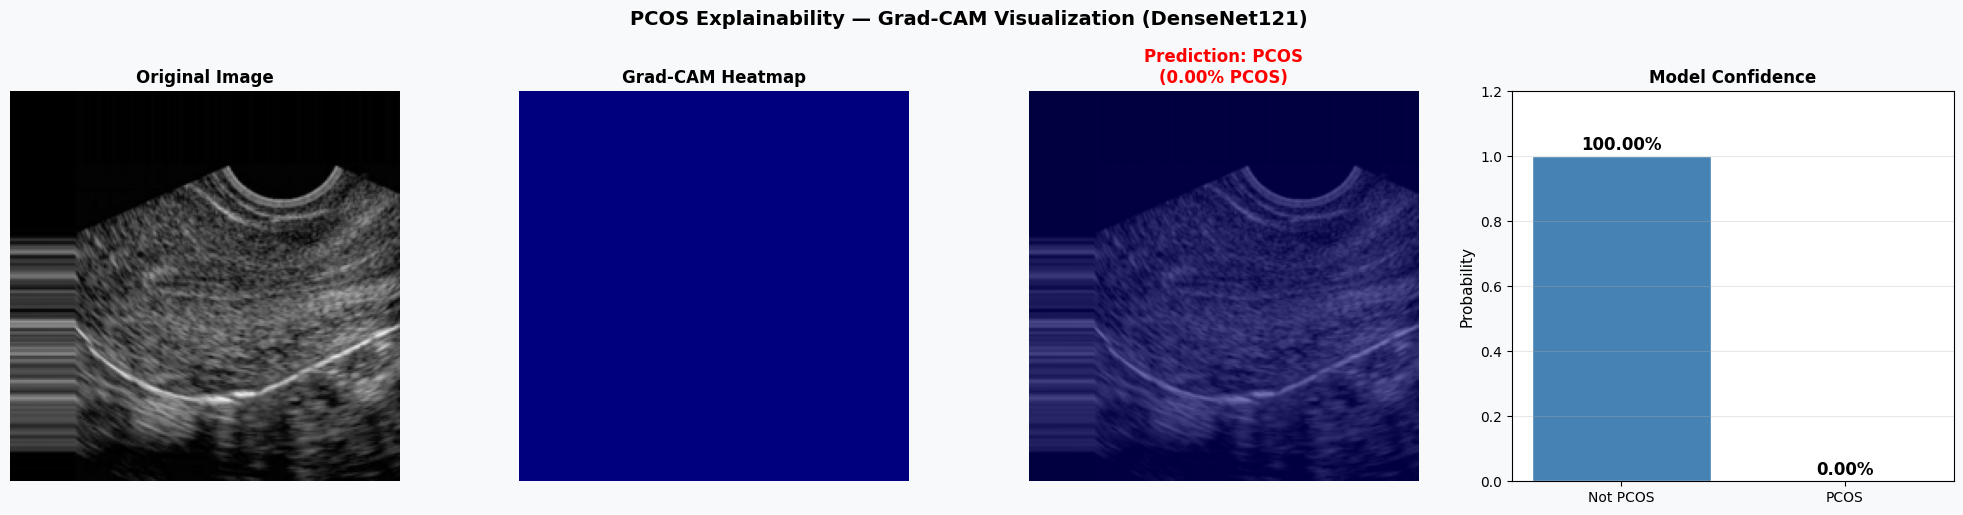

In [ ]:


# ─────────────────────────────────────────────────────────────────────────────
# BLOCK 8 ▸ RUN GRAD-CAM ON SAMPLE IMAGES
# ─────────────────────────────────────────────────────────────────────────────
# Run on 2 PCOS + 2 Non-PCOS samples from test set
VALID_EXT = ('.png', '.jpg', '.jpeg')
samples   = []

for label_folder, true_lbl in [("pcos", "PCOS"), ("not_pcos", "Not PCOS")]:
    folder = os.path.join(TEST_DIR, label_folder)
    files  = [f for f in os.listdir(folder) if f.lower().endswith(VALID_EXT)][:2]
    for f in files:
        samples.append((os.path.join(folder, f), true_lbl))

print(f"\nRunning Grad-CAM on {len(samples)} sample images...")

for i, (img_path, true_label) in enumerate(samples):
    print(f"\n[{i+1}/{len(samples)}] {true_label} — {os.path.basename(img_path)}")

    result    = get_gradcam_heatmap(img_path, model, class_idx=1)  # class_idx=1 = PCOS
    save_path = os.path.join(RESULT_DIR, f"gradcam_{true_label.replace(' ','_')}_{i+1}.png")

    print(f"   Prediction : {result['pred_label']} ({result['prob_pcos']*100:.2f}% PCOS)")
    plot_gradcam(result, true_label=true_label, save_path=save_path)


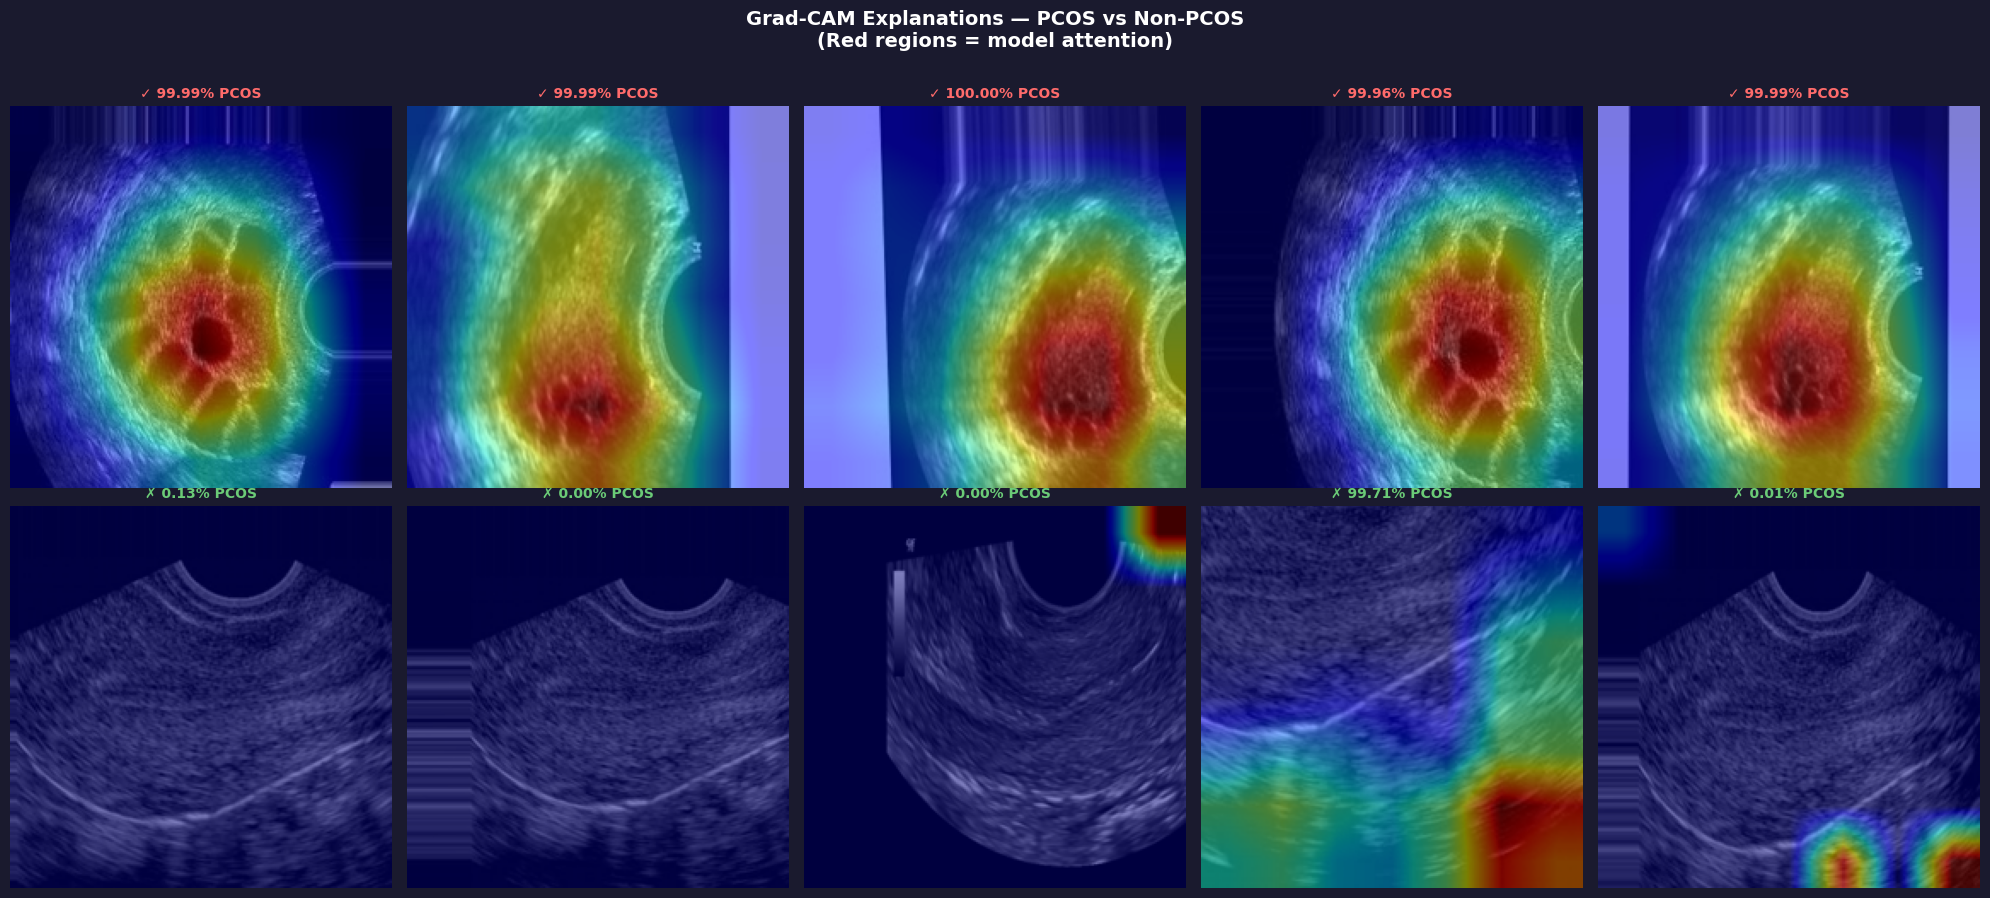


✅ Grad-CAM grid saved → /content/drive/MyDrive/PCOS_Image_Results2/GradCAM/gradcam_grid.png

✅ Grad-CAM COMPLETE — all explanations saved to Drive
   📁 /content/drive/MyDrive/PCOS_Image_Results2/GradCAM


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# BLOCK 9 ▸ BATCH GRAD-CAM — all test images, save grid
# ─────────────────────────────────────────────────────────────────────────────
def batch_gradcam_grid(test_dir, n_per_class=5):
    """
    Creates a grid of Grad-CAM overlays:
    Top row    : PCOS images
    Bottom row : Non-PCOS images
    Saves as single research-quality figure.
    """
    VALID_EXT = ('.png', '.jpg', '.jpeg')
    fig, axes = plt.subplots(2, n_per_class, figsize=(n_per_class * 4, 9))
    fig.patch.set_facecolor("#1a1a2e")

    for row, (label_folder, true_lbl, row_color) in enumerate([
        ("pcos",     "PCOS",     "#ff6b6b"),
        ("not_pcos", "Not PCOS", "#6bcb77")
    ]):
        folder = os.path.join(test_dir, label_folder)
        files  = [f for f in os.listdir(folder) if f.lower().endswith(VALID_EXT)][:n_per_class]

        for col, fname in enumerate(files):
            img_path = os.path.join(folder, fname)
            result   = get_gradcam_heatmap(img_path, model, class_idx=1)

            axes[row][col].imshow(result["overlay"])
            axes[row][col].axis("off")

            pred_correct = (result["pred_class"] == 1) == (label_folder == "pcos")
            tick = "✓" if pred_correct else "✗"
            axes[row][col].set_title(
                f"{tick} {result['prob_pcos']*100:.2f}% PCOS",
                fontsize=10, color=row_color, fontweight="bold"
            )

        axes[row][0].set_ylabel(true_lbl, fontsize=13,
                                 color=row_color, fontweight="bold",
                                 rotation=90, labelpad=10)

    plt.suptitle("Grad-CAM Explanations — PCOS vs Non-PCOS\n(Red regions = model attention)",
                 fontsize=14, fontweight="bold", color="white", y=1.01)
    plt.tight_layout()

    save_path = os.path.join(RESULT_DIR, "gradcam_grid.png")
    plt.savefig(save_path, dpi=150, bbox_inches="tight",
                facecolor="#1a1a2e")
    plt.show()
    plt.close()
    print(f"\n✅ Grad-CAM grid saved → {save_path}")

batch_gradcam_grid(TEST_DIR, n_per_class=5)

print("\n✅ Grad-CAM COMPLETE — all explanations saved to Drive")
print(f"   📁 {RESULT_DIR}")

In [ ]:
import os

# Tabular models
path = "/content/drive/MyDrive/PCOS_RESULTS_TABULAR/deployment/"
print("=== TABULAR MODELS ===")
for f in os.listdir(path):
    size = os.path.getsize(path+f)/(1024*1024)
    print(f"{f:40s}  {size:.1f} MB")

# Image model
img_path = "/content/drive/MyDrive/PCOS_RESULTS/EfficientNetB0/best_model.pth"
size = os.path.getsize(img_path)/(1024*1024)
print(f"\n=== IMAGE MODEL ===")
print(f"best_model.pth  {size:.1f} MB")

=== TABULAR MODELS ===
ensemble_meta.pkl                         0.0 MB
feature_columns.pkl                       0.0 MB
best_threshold.pkl                        0.0 MB
train_stats.pkl                           0.0 MB
deployment_config.json                    0.0 MB
base_models.pkl                           5.2 MB
mice_imputer.pkl                          1.2 MB
domain_models.pkl                         0.8 MB
scaler.pkl                                0.0 MB

=== IMAGE MODEL ===
best_model.pth  46.4 MB
